<a href="https://colab.research.google.com/github/aymuos/starship/blob/main/fundamental_EDA/feature_creator_cq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Feature creator notebook for Chongqing

In [30]:
!pip install duckdb polars pyarrow

In [31]:
CITY_IN_QUES = 'Chongqing'

## Objective

- create features using both the datasets
-

In [32]:
# local

base = "../dataset/ml/PROCESSED/matched/city_divided/"

In [33]:
base = "/content/drive/MyDrive/ml/PROCESSED/matched/city_divided/"

idea : trajectory[t−Δ , t]  →  delivery(t) where t = receipt_time
Δ = 15 minutes (initial)

In [34]:
import polars as pl

cq_delivery = base + "chongqing_data.csv"
cq_gps = base + "chongqing_delivery_data.parquet"

# Load the CSV file
chongqing_df_csv = pl.read_csv(cq_delivery)
print("\nChongqing CSV DataFrame (head 5):")
print(chongqing_df_csv.head(5))

# Load the Parquet file
chongqing_df_parquet = pl.read_parquet(cq_gps)
print("\nChongqing Parquet DataFrame (head 5):")
print(chongqing_df_parquet.head(5))


Chongqing CSV DataFrame (head 5):
shape: (5, 16)
┌─────────────┬─────────────┬────────────┬──────────┬───┬──────────┬─────┬────────────┬────────────┐
│ order_id    ┆ from_dipan_ ┆ delivery_u ┆ poi_lng  ┆ … ┆ sign_lat ┆ ds  ┆ from_city_ ┆ horizon_ET │
│ ---         ┆ id          ┆ ser_id     ┆ ---      ┆   ┆ ---      ┆ --- ┆ en         ┆ A          │
│ str         ┆ ---         ┆ ---        ┆ f64      ┆   ┆ str      ┆ i64 ┆ ---        ┆ ---        │
│             ┆ str         ┆ str        ┆          ┆   ┆          ┆     ┆ str        ┆ f64        │
╞═════════════╪═════════════╪════════════╪══════════╪═══╪══════════╪═════╪════════════╪════════════╡
│ 55be8cdf127 ┆ c5ac5ba9980 ┆ df0b594618 ┆ 8.8999e6 ┆ … ┆ null     ┆ 318 ┆ Chongqing  ┆ 361.0      │
│ 0526231c9ba ┆ 1aa6b85ba47 ┆ d1ba6f619e ┆          ┆   ┆          ┆     ┆            ┆            │
│ 3387f51b…   ┆ 3d926051…   ┆ 4e7dd03444 ┆          ┆   ┆          ┆     ┆            ┆            │
│             ┆             ┆ …          

In [35]:
chongqing_df_csv = chongqing_df_csv.with_columns([
    pl.col("receipt_time").str.to_datetime("%Y-%m-%d %H:%M:%S").alias("receipt_time"),
    pl.col("sign_time").str.to_datetime("%Y-%m-%d %H:%M:%S").alias("sign_time")
])

print("Chongqing CSV DataFrame with updated time column types:")
print(chongqing_df_csv.head(5))

Chongqing CSV DataFrame with updated time column types:
shape: (5, 16)
┌─────────────┬─────────────┬────────────┬──────────┬───┬──────────┬─────┬────────────┬────────────┐
│ order_id    ┆ from_dipan_ ┆ delivery_u ┆ poi_lng  ┆ … ┆ sign_lat ┆ ds  ┆ from_city_ ┆ horizon_ET │
│ ---         ┆ id          ┆ ser_id     ┆ ---      ┆   ┆ ---      ┆ --- ┆ en         ┆ A          │
│ str         ┆ ---         ┆ ---        ┆ f64      ┆   ┆ str      ┆ i64 ┆ ---        ┆ ---        │
│             ┆ str         ┆ str        ┆          ┆   ┆          ┆     ┆ str        ┆ f64        │
╞═════════════╪═════════════╪════════════╪══════════╪═══╪══════════╪═════╪════════════╪════════════╡
│ 55be8cdf127 ┆ c5ac5ba9980 ┆ df0b594618 ┆ 8.8999e6 ┆ … ┆ null     ┆ 318 ┆ Chongqing  ┆ 361.0      │
│ 0526231c9ba ┆ 1aa6b85ba47 ┆ d1ba6f619e ┆          ┆   ┆          ┆     ┆            ┆            │
│ 3387f51b…   ┆ 3d926051…   ┆ 4e7dd03444 ┆          ┆   ┆          ┆     ┆            ┆            │
│             ┆     

In [36]:
print("Chongqing CSV DataFrame schema after datetime conversion:")
print(chongqing_df_csv.schema)

Chongqing CSV DataFrame schema after datetime conversion:
Schema({'order_id': String, 'from_dipan_id': String, 'delivery_user_id': String, 'poi_lng': Float64, 'poi_lat': Float64, 'aoi_id': String, 'typecode': String, 'receipt_time': Datetime(time_unit='us', time_zone=None), 'receipt_lng': Float64, 'receipt_lat': Float64, 'sign_time': Datetime(time_unit='us', time_zone=None), 'sign_lng': String, 'sign_lat': String, 'ds': Int64, 'from_city_en': String, 'horizon_ETA': Float64})


In [37]:
chongqing_df_csv = chongqing_df_csv.drop(["sign_lat", "sign_lng"])

print("Chongqing CSV DataFrame after dropping sign_lat and sign_lng (head 5):")
print(chongqing_df_csv.head(5))

print("\nChongqing CSV DataFrame schema after dropping sign_lat and sign_lng:")
print(chongqing_df_csv.schema)

Chongqing CSV DataFrame after dropping sign_lat and sign_lng (head 5):
shape: (5, 14)
┌────────────┬────────────┬────────────┬──────────┬───┬────────────┬─────┬────────────┬────────────┐
│ order_id   ┆ from_dipan ┆ delivery_u ┆ poi_lng  ┆ … ┆ sign_time  ┆ ds  ┆ from_city_ ┆ horizon_ET │
│ ---        ┆ _id        ┆ ser_id     ┆ ---      ┆   ┆ ---        ┆ --- ┆ en         ┆ A          │
│ str        ┆ ---        ┆ ---        ┆ f64      ┆   ┆ datetime[μ ┆ i64 ┆ ---        ┆ ---        │
│            ┆ str        ┆ str        ┆          ┆   ┆ s]         ┆     ┆ str        ┆ f64        │
╞════════════╪════════════╪════════════╪══════════╪═══╪════════════╪═════╪════════════╪════════════╡
│ 55be8cdf12 ┆ c5ac5ba998 ┆ df0b594618 ┆ 8.8999e6 ┆ … ┆ 2021-03-18 ┆ 318 ┆ Chongqing  ┆ 361.0      │
│ 70526231c9 ┆ 01aa6b85ba ┆ d1ba6f619e ┆          ┆   ┆ 14:33:00   ┆     ┆            ┆            │
│ ba3387f51b ┆ 473d926051 ┆ 4e7dd03444 ┆          ┆   ┆            ┆     ┆            ┆            │
│ …  

Feature creation starts
---


---


In [38]:
# cast to utf8 and sort by user_id and rept time
delivery = (
    chongqing_df_csv
    .rename({"horizon_ETA": "eta_mins"})
    .with_columns(
        pl.col("delivery_user_id").cast(pl.Utf8)
    )
    .sort(["delivery_user_id", "receipt_time"])
)

In [39]:
# defining just the gps extraction windows

start_time = delivery["receipt_time"].min()
end_time   = delivery["receipt_time"].max()

couriers = delivery["delivery_user_id"].unique().to_list()

print(len(couriers), "couriers")

145 couriers


In [40]:
# initialise duckdb and selects data between start and end times in courier

import duckdb

con = duckdb.connect()

PRE_MIN = 15

gps_df = con.execute(f"""
SELECT
    postman_id,
    gps_time,
    lat,
    lng
FROM parquet_scan('{base}chongqing_delivery_data.parquet')
WHERE
    postman_id IN {tuple(couriers)}
    AND gps_time BETWEEN
        TIMESTAMP '{start_time}' - INTERVAL '{PRE_MIN} minutes'
        AND TIMESTAMP '{end_time}'
""").pl()

gps_df = gps_df.rename({"postman_id": "delivery_user_id"})
gps_df = gps_df.sort(["delivery_user_id", "gps_time"])

In [41]:
# Courier Snapshot Before Delivery (ASOF JOIN)

state = delivery.join_asof(
    gps_df,
    left_on="receipt_time",
    right_on="gps_time",
    by="delivery_user_id",
    strategy="backward"
).rename({
    "lat": "last_x",
    "lng": "last_y",              # for each receipt_time in the delivery DataFrame, Polars looks for the latest gps_time in gps_df that is less than or equal to the receipt_time. This gives us the last known GPS position of the courier before the order was received
    "gps_time": "last_gps_time"
})



# for each receipt_time in the delivery DataFrame, Polars looks for the latest gps_time in gps_df that is less than or equal to the receipt_time.
# This gives us the last known GPS position of the courier before the order was received

/tmp/ipykernel_461/2926050772.py:3: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  state = delivery.join_asof(


In [42]:
# GPS Freshness Feature
state = state.with_columns(
    (pl.col("receipt_time") - pl.col("last_gps_time"))
        .dt.total_minutes()
        .alias("gps_gap_min")
)

In [43]:
state.schema

Schema([('order_id', String),
        ('from_dipan_id', String),
        ('delivery_user_id', String),
        ('poi_lng', Float64),
        ('poi_lat', Float64),
        ('aoi_id', String),
        ('typecode', String),
        ('receipt_time', Datetime(time_unit='us', time_zone=None)),
        ('receipt_lng', Float64),
        ('receipt_lat', Float64),
        ('sign_time', Datetime(time_unit='us', time_zone=None)),
        ('ds', Int64),
        ('from_city_en', String),
        ('eta_mins', Float64),
        ('last_gps_time', Datetime(time_unit='us', time_zone=None)),
        ('last_x', Float64),
        ('last_y', Float64),
        ('gps_gap_min', Int64)])

In [44]:
state.select("gps_gap_min").describe()

statistic,gps_gap_min
str,f64
"""count""",19062.0
"""null_count""",7608.0
"""mean""",315.771168
"""std""",1520.738809
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",0.0
"""max""",15808.0


High sd = wide spread in gps_gap_min , meaning the gap vary heavily from mean of 315 mins . for at least 75% of the deliveries where GPS data was found, the courier had a GPS update exactly at the receipt_time or very, very close to it. This suggests a strong clustering of GPS updates around the receipt time. The maximum gps_gap_min is 15,808 minutes (over 263 hours or about 11 days!). This is an extremely large gap and indicates that for some deliveries, the last recorded GPS point for the courier was very, very old. These outliers are likely what's driving the high mean and standard deviation, despite the quartiles being 0

gps_time ≤ receipt_time is ensured by asof_join . Invalidate stale gps matches : GPS older than 30 minutes → unusable

In [45]:
MAX_GAP = 30  # 30 minutes is a commonly adopted practical threshold

state = state.with_columns(
    pl.when(pl.col("gps_gap_min") <= MAX_GAP)
      .then(pl.col("gps_gap_min"))
      .otherwise(None)
      .alias("gps_gap_min")
)

#  invalidates those GPS matches, as they are deemed too old to be reliable for the specific receipt time.


In [46]:
state = state.with_columns([
    pl.when(pl.col("gps_gap_min").is_null())
      .then(None)
      .otherwise(pl.col("last_x"))
      .alias("last_x"),

    pl.when(pl.col("gps_gap_min").is_null())
      .then(None)
      .otherwise(pl.col("last_y"))
      .alias("last_y"),
])


# idea is to prevent stale gps from corrupting matches

In lade Delivery coverage > GPS coverage , So GPS must be treated as:
optional contextual sensor not guaranteed observation. This will influence later bandit formulation.

Identifying Causal Factors: gps_gap_min could be a cause for other operational metrics. For example, a high gps_gap_min (stale GPS) might causally lead to:

Increased variance or error in estimated ETAs.
Changes in dispatching strategies (e.g., dispatchers might assign fewer new orders if a courier's location is uncertain).
Longer actual delivery times, as couriers might take sub-optimal routes if real-time navigation is compromised.

Handling Confounding/Mediation: gps_gap_min might act as a confounder or mediator in causal paths between other variables. For example, if you're trying to understand the causal impact of 'courier speed' on 'delivery delay', and gps_gap_min is correlated with both (e.g., very slow recorded speeds often coincide with stale GPS in certain areas), PCMCI+ can help disentangle these relationships by conditioning on gps_gap_min.


gps_gap_min provides a quantifiable measure of information quality or state uncertainty, allowing for more robust causal inference and more adaptive, data-driven decision-making

In [47]:
# diagonistic code

state.select([
    pl.len().alias("rows"),
    pl.col("gps_gap_min").null_count().alias("missing_gps"),
    pl.mean("gps_gap_min").alias("mean_gap"),
    pl.median("gps_gap_min").alias("median_gap"),
])

rows,missing_gps,mean_gap,median_gap
u32,u32,f64,f64
26670,9472,0.324689,0.0


This means :

- rows          = 26670 deliveries
- missing_gps   = 9472  (~35%)
- mean_gap      = 0.32 minutes
- median_gap    = 0.0 minutes

---

- Most deliveries have a GPS sample almost exactly at receipt_time.
- mean_gap < 1 minute i.e stale gps are removed


In [48]:
state.schema

Schema([('order_id', String),
        ('from_dipan_id', String),
        ('delivery_user_id', String),
        ('poi_lng', Float64),
        ('poi_lat', Float64),
        ('aoi_id', String),
        ('typecode', String),
        ('receipt_time', Datetime(time_unit='us', time_zone=None)),
        ('receipt_lng', Float64),
        ('receipt_lat', Float64),
        ('sign_time', Datetime(time_unit='us', time_zone=None)),
        ('ds', Int64),
        ('from_city_en', String),
        ('eta_mins', Float64),
        ('last_gps_time', Datetime(time_unit='us', time_zone=None)),
        ('last_x', Float64),
        ('last_y', Float64),
        ('gps_gap_min', Int64)])

# Building trajectory window

In [49]:
# Registering table in duckDB

con.register("delivery_tbl", delivery.to_pandas())

In [50]:
stats = con.execute(f"SELECT MAX(lat) - MIN(lat) as height, MAX(lng) - MIN(lng) as width FROM parquet_scan('{cq_gps}')").fetchone()
print(f"Data spans {stats[0]:.2f} by {stats[1]:.2f} units.")


Data spans 1120353.20 by 3769203.19 units.


In [51]:
# objective : calculate percentile based speed threshold 99th percentile
# uses window function to compare each GPS point with the one immediately preceding it for the same postman


speed_q = con.execute(f"""
WITH motion AS (

    SELECT
        SQRT(
            POWER(lat - LAG(lat) OVER w, 2) +
            POWER(lng - LAG(lng) OVER w, 2)
        ) AS dist,

        EXTRACT(EPOCH FROM (
            gps_time - LAG(gps_time) OVER w
        )) AS dt

    FROM parquet_scan('{cq_gps}')

    WINDOW w AS (
        PARTITION BY postman_id
        ORDER BY gps_time
    )
),

clean AS (
    SELECT
        dist / dt AS speed
    FROM motion
    WHERE
        dt > 5           -- remove duplicates , ignores less than 5 secs
        AND dt < 600     -- remove long gaps , ignores gaps less than 10 mins
        AND dist < 10000 -- teleportation guard , ignores massive coordinate jumps
)
SELECT quantile_cont(speed, 0.99)
FROM clean
""").fetchone()[0]

print(speed_q)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

12.22464498399561


calculate a robust 99th percentile speed threshold from your GPS data. This threshold helps identify and filter out unrealistic or erroneous speed measurements in subsequent feature engineering.

In [52]:
PRE_MIN = 15

traj_features = con.execute(f"""
WITH gps_window AS (

    SELECT
        d.order_id,
        g.gps_time,
        g.lat,
        g.lng,

        LAG(g.lat) OVER (
            PARTITION BY d.order_id
            ORDER BY g.gps_time
        ) AS prev_lat,

        LAG(g.lng) OVER (
            PARTITION BY d.order_id
            ORDER BY g.gps_time
        ) AS prev_lng,

        LAG(g.gps_time) OVER (
            PARTITION BY d.order_id
            ORDER BY g.gps_time
        ) AS prev_time

    FROM delivery_tbl d
    JOIN parquet_scan('{cq_gps}') g
      ON g.postman_id = d.delivery_user_id

    WHERE g.gps_time BETWEEN
        d.receipt_time - INTERVAL '{PRE_MIN} minutes'
        AND d.receipt_time
),

motion AS (

    SELECT
        order_id,

        SQRT(
            POWER(lat - prev_lat, 2) +
            POWER(lng - prev_lng, 2)
        ) AS dist,

        EXTRACT(EPOCH FROM (gps_time - prev_time)) AS dt

    FROM gps_window
),

speed_calc AS (


    SELECT
        order_id,
        dist,
        dt,

        CASE
            WHEN dt IS NULL THEN NULL
            WHEN dt <= 1 THEN NULL        -- remove tiny intervals
            WHEN dist > 5000 THEN NULL   -- teleportation filter
            WHEN dist / dt > 5 THEN NULL   -- speed cap for not natural speed  #TODO Need to change with percentile based methods
            ELSE dist / dt
        END AS speed

    FROM motion
)

SELECT
    order_id,
    COUNT(*) AS gps_points,
    AVG(speed) AS speed_mean,
    SUM(dist) AS distance_travelled

FROM speed_calc
GROUP BY order_id
""").pl()


# calculates the number of GPS points, mean speed, and total distance traveled for each order.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [53]:
traj_features.head()

order_id,gps_points,speed_mean,distance_travelled
str,i64,f64,f64
"""01adbac333cecaf7c442b6fcb8ae71…",45,0.799867,703.883041
"""02b6c8050848d24bb31baa5dbf9fae…",45,0.063843,56.18146
"""04395b12e1f47d91fff2dcc8497a22…",26,0.072273,6.1557e6
"""09f171274d0d531707bd2e9871b7a1…",6,0.0,0.0
"""2a4bf32615adbf5b621d7573c96604…",38,0.0,0.0


dt <= 1

GPS sampling ≈ 20 seconds.

Anything ≤1 sec is noise.

dist > 5000

Affine coordinates behave like meters-scale space. A courier cannot move 5 km between samples.

This removes privacy jumps.

## conclusion from this data :

- order_id = unique identifier
- gps_points = how many valid GPS data points were used to calculate the trajectory features for that specific order within the 15-minute window before receipt_time.
- speed_mean= average speed of the courier during that 15-minute window before the order was received, calculated from the filtered GPS segments.
- distance_travelled =  total distance covered by the courier during the 15-minute window, based on the cleaned and filtered GPS segments.



In [54]:
traj_features.select([
    pl.max("speed_mean").alias("max_speed_mean"),
    pl.mean("speed_mean").alias("mean_speed_mean")
])

max_speed_mean,mean_speed_mean
f64,f64
2.967034,0.492363


conclusion from this is :
missing GPS samples
→ courier reappears far away
→ large dist but moderate dt


Instead of trying to perfectly clean GPS (impossible), we winsorize speeds.

This is standard in:

Uber ETA systems

mobility forecasting

trajectory ML papers

This adding of limit of 5 helped us do trajectory signal extraction
NOT GPS reconstruction

speed_q (99th percentile speed) of 12.22 also gives context to the range of speeds in this arbitrary unit.

speed_max_mean is 2.96 in that same unit
speed_min_mean is 0.492 in that unit

it indicates whether a courier was moving faster or slower relative to other couriers or their own past movements within this transformed space. It's a feature that captures activity level rather than an absolute physical velocity.

---
Adding eucledian distance feature

In [55]:
print("Coordinate Statistics in Delivery DataFrame:")
display(delivery.select(["poi_lng", "poi_lat", "receipt_lng", "receipt_lat"]).describe())

print("\nNull counts for coordinates:")
display(delivery.select([
    pl.col("poi_lng").null_count().alias("null_poi_lng"),
    pl.col("poi_lat").null_count().alias("null_poi_lat"),
    pl.col("receipt_lng").null_count().alias("null_receipt_lng"),
    pl.col("receipt_lat").null_count().alias("null_receipt_lat")
]))

print("\nFirst 5 rows of coordinates:")
display(delivery.select(["order_id", "poi_lng", "poi_lat", "receipt_lng", "receipt_lat"]).head(5))

Coordinate Statistics in Delivery DataFrame:


statistic,poi_lng,poi_lat,receipt_lng,receipt_lat
str,f64,f64,f64,f64
"""count""",26670.0,26670.0,26670.0,26670.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",8.9083e6,-7.6777e6,8.9079e6,-7.6777e6
"""std""",27219.515397,23431.006165,27507.086182,23248.727266
"""min""",8.7973e6,-7.7683e6,8.8205e6,-7.7250e6
"""25%""",8.9033e6,-7.6868e6,8.9040e6,-7.6861e6
"""50%""",8.9089e6,-7.6814e6,8.9088e6,-7.6817e6
"""75%""",8.9130e6,-7.6734e6,8.9123e6,-7.6746e6
"""max""",9.1249e6,-7.5101e6,9.1117e6,-7.5227e6



Null counts for coordinates:


null_poi_lng,null_poi_lat,null_receipt_lng,null_receipt_lat
u32,u32,u32,u32
0,0,0,0



First 5 rows of coordinates:


order_id,poi_lng,poi_lat,receipt_lng,receipt_lat
str,f64,f64,f64,f64
"""7b15e523a08ad352b9f22bb4ecd998…",8.9031e6,-7.6873e6,8.9041e6,-7.6866e6
"""3d7ca50514737df23244a2c633b7ee…",8.9035e6,-7.6870e6,8.9041e6,-7.6866e6
"""5134623a6ae48bf37cc58bbcb22412…",8.9028e6,-7.6875e6,8.9041e6,-7.6866e6
"""95334065d9951e356138196715ba21…",8.9032e6,-7.6870e6,8.9041e6,-7.6866e6
"""4767aafe217550daac5895cbc46b46…",8.9030e6,-7.6871e6,8.9041e6,-7.6866e6


In [56]:
import numpy as np

# Calculate distance on the base delivery dataframe
delivery = delivery.with_columns(
    ((pl.col("receipt_lng") - pl.col("poi_lng")).pow(2) +
     (pl.col("receipt_lat") - pl.col("poi_lat")).pow(2)).sqrt()
    .alias("pickup_destination_distance")
)



---

# Batch rank calculation

- How many orders a courier accepts simultaneously and the rank of a particular order within that batch. This is important for understanding courier workload and potential delays.

In [57]:
# batch rank stuff - sort first

delivery = delivery.sort([
    "delivery_user_id",
    "receipt_time",
    "order_id"   # tie-breaker (critical when multiple orders are received at same time instance)
])

# compute batch_size

delivery = delivery.with_columns(
    pl.len()
      .over(["delivery_user_id", "receipt_time"])
      .alias("batch_size")
)

# compute batch rank
delivery = delivery.with_columns(
    pl.int_range(
        0,
        pl.len()
    ).over(["delivery_user_id", "receipt_time"])
    .alias("batch_rank")
)                                        # creates a range from 0 to length of current group , thus creates an ordinal rank

# TODO : Possible bug ? batch no not resetting after batch_rank completes

# batch rank ends here

# Computing statistical distribution


- **motion CTE**: It uses a window function LAG to compare each GPS point with the one immediately preceding it for the same courier (postman_id). It calculates the Euclidean distance (dist) in transformed units and the time difference (dt) in seconds.
- **clean CTE**: This filters the raw movement data. It ensures dt > 0 to avoid division-by-zero errors (identical timestamps) and removes nulls to ensure every record has a valid movement signature.
- **SELECT speed**: It finally calculates dist / dt and returns a Polars DataFrame containing every valid instantaneous speed recorded in the dataset.

In [58]:


speed_df = con.execute(f"""
WITH motion AS (

    SELECT
        SQRT(
            POWER(lat - LAG(lat) OVER w, 2) +
            POWER(lng - LAG(lng) OVER w, 2)
        ) AS dist,

        EXTRACT(EPOCH FROM (
            gps_time - LAG(gps_time) OVER w
        )) AS dt

    FROM parquet_scan('{cq_gps}')

    WINDOW w AS (
        PARTITION BY postman_id
        ORDER BY gps_time
    )
),

clean AS (
    SELECT
        dist/dt AS speed
    FROM motion
    WHERE
        dt IS NOT NULL
        AND dt > 0
        AND dist IS NOT NULL
)

SELECT speed
FROM clean
WHERE speed IS NOT NULL
""").pl()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [59]:
# compute CCDF - goal plot on a log-log scale to identify if the courier's movement
# follows a specific statistical pattern, like a Power Law

speed_df = speed_df.sort("speed")

n = speed_df.height

ccdf = speed_df.with_row_count("rank").with_columns(
    (1 - (pl.col("rank") / n)).alias("ccdf")
).select(["speed", "ccdf"])

/tmp/ipykernel_461/1716921051.py:8: DeprecationWarning: `DataFrame.with_row_count` is deprecated; use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  ccdf = speed_df.with_row_count("rank").with_columns(


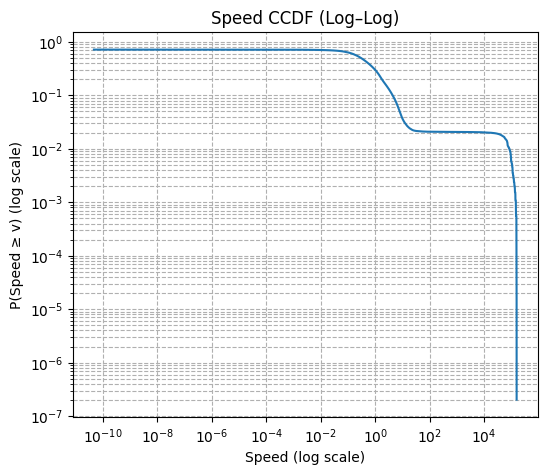

In [60]:
# PLot log-log CCDF

import matplotlib.pyplot as plt
import numpy as np

s = ccdf["speed"].to_numpy()
p = ccdf["ccdf"].to_numpy()

mask = (s > 0) & (p > 0)

plt.figure(figsize=(6,5))
plt.loglog(s[mask], p[mask])

plt.xlabel("Speed (log scale)")
plt.ylabel("P(Speed ≥ v) (log scale)")
plt.title("Speed CCDF (Log–Log)")
plt.grid(True, which="both", ls="--")

plt.show()

THe graph has a sharp drop off at the very end . Graph help prove that the courier movement is hetero genous . Heavy tail on the right proves the movement between delivery zones. The graph confirms that the trajectory signal extraction is capturing actual movement behavior rather than just random noise

In [61]:
# JOIN STATE , TRAJECTORY FEATURES WITH DELIVERY FEATURES

# -----------------------------------------------------------------

features = (
    delivery
      .join(state.select(["order_id","last_x","last_y","gps_gap_min"]), on="order_id", how="left")
      .join(traj_features, on="order_id", how="left")
)

# Join the new feature into the features dataframe
features = features.join(
    delivery.select(["order_id", "pickup_destination_distance"]),
    on="order_id",
    how="left"
)

print("Euclidean distance calculated and joined to features.")
display(features.select(["order_id", "pickup_destination_distance"]).head())

Euclidean distance calculated and joined to features.


order_id,pickup_destination_distance
str,f64
"""7b15e523a08ad352b9f22bb4ecd998…",1247.315938
"""3d7ca50514737df23244a2c633b7ee…",763.699221
"""5134623a6ae48bf37cc58bbcb22412…",1568.190039
"""95334065d9951e356138196715ba21…",1007.927018
"""4767aafe217550daac5895cbc46b46…",1273.960789


In [62]:
features.select([
    pl.len().alias("rows"),
    pl.mean("gps_points"),
    pl.mean("speed_mean"),
    pl.mean("eta_mins")
])

rows,gps_points,speed_mean,eta_mins
u32,f64,f64,f64
26670,34.390476,0.492363,285.018823


In [63]:
# Validation: Find batches with more than one order -> batch_size and batch_rank
batch_check = features.filter(pl.col("batch_size") > 1).select([
    "delivery_user_id",
    "receipt_time",
    "order_id",
    "batch_size",
    "batch_rank"
]).sort(["delivery_user_id", "receipt_time", "batch_rank"])

print("Example of multi-order batches:")
display(batch_check.head(15))

Example of multi-order batches:


delivery_user_id,receipt_time,order_id,batch_size,batch_rank
str,datetime[μs],str,u32,i64
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:21:00,"""3d7ca50514737df23244a2c633b7ee…",3,0
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:21:00,"""5134623a6ae48bf37cc58bbcb22412…",3,1
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:21:00,"""95334065d9951e356138196715ba21…",3,2
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:24:00,"""1976e7cb9e4c10c25a555da3be51e8…",3,0
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 08:24:00,"""60e2c8af8b3f4a692bccb16403e87e…",3,1
…,…,…,…,…
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 14:51:00,"""06437740f7a1fcb33e09e93ef22c86…",2,0
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-18 14:51:00,"""df13ce63066334c1aa65953265fcae…",2,1
"""0008c2b6a2314db8715301b7eeeebc…",2021-03-19 08:18:00,"""6f6949c040abd1ae2e145ddcae7873…",3,0


merging state and trajectory_features to features mother dataframe

In [64]:
# adding temporal context

features = features.with_columns([
    pl.col("receipt_time").dt.hour().alias("hour"),
    pl.col("receipt_time").dt.weekday().alias("weekday"),

    pl.col("order_id").cum_count().over("delivery_user_id")
        .alias("delivery_sequence")
])

In [65]:
# Adding weekend and holiday features
# Based on 2021 calendar:
# March 21 to April 20 range
# Qingming Festival: April 3, 4, 5 (Saturday, Sunday, Monday)

features = features.with_columns([
    # Weekend flag for Polars default weekday is 1-7 (Monday-Sunday)
    (pl.col("weekday") >= 6).cast(pl.Int8).alias("is_weekend"),

    # Holiday flag (Qingming Festival 2021: April 3-5)
    ((
        (pl.col("receipt_time").dt.month() == 4) &
        (pl.col("receipt_time").dt.day().is_in([3, 4, 5]))
    )).cast(pl.Int8).alias("is_holiday")
])

print("Added is_weekend and is_holiday features.")
print(features.select(["receipt_time", "weekday", "is_weekend", "is_holiday"]).head())

Added is_weekend and is_holiday features.
shape: (5, 4)
┌─────────────────────┬─────────┬────────────┬────────────┐
│ receipt_time        ┆ weekday ┆ is_weekend ┆ is_holiday │
│ ---                 ┆ ---     ┆ ---        ┆ ---        │
│ datetime[μs]        ┆ i8      ┆ i8         ┆ i8         │
╞═════════════════════╪═════════╪════════════╪════════════╡
│ 2021-03-18 08:20:00 ┆ 4       ┆ 0          ┆ 0          │
│ 2021-03-18 08:21:00 ┆ 4       ┆ 0          ┆ 0          │
│ 2021-03-18 08:21:00 ┆ 4       ┆ 0          ┆ 0          │
│ 2021-03-18 08:21:00 ┆ 4       ┆ 0          ┆ 0          │
│ 2021-03-18 08:23:00 ┆ 4       ┆ 0          ┆ 0          │
└─────────────────────┴─────────┴────────────┴────────────┘


In [66]:
# # Aggregate by date to see the volume spike
# daily_stats = (
#     features.group_by(["from_city_en", pl.col("receipt_time").dt.date()])
#     .agg([
#         pl.len().alias("order_count"),
#         pl.mean("batch_total_size").alias("avg_batch_size"),
#         pl.mean("speed_mean").alias("avg_speed")
#     ])
#     .sort("receipt_time")
# )

# # Identify the 'Peak' days
# peak_days = daily_stats.filter(pl.col("order_count") > pl.col("order_count").mean() + pl.col("order_count").std())
# print(peak_days)

In [67]:
features.schema

Schema([('order_id', String),
        ('from_dipan_id', String),
        ('delivery_user_id', String),
        ('poi_lng', Float64),
        ('poi_lat', Float64),
        ('aoi_id', String),
        ('typecode', String),
        ('receipt_time', Datetime(time_unit='us', time_zone=None)),
        ('receipt_lng', Float64),
        ('receipt_lat', Float64),
        ('sign_time', Datetime(time_unit='us', time_zone=None)),
        ('ds', Int64),
        ('from_city_en', String),
        ('eta_mins', Float64),
        ('pickup_destination_distance', Float64),
        ('batch_size', UInt32),
        ('batch_rank', Int64),
        ('last_x', Float64),
        ('last_y', Float64),
        ('gps_gap_min', Int64),
        ('gps_points', Int64),
        ('speed_mean', Float64),
        ('distance_travelled', Float64),
        ('pickup_destination_distance_right', Float64),
        ('hour', Int8),
        ('weekday', Int8),
        ('delivery_sequence', UInt32),
        ('is_weekend', Int8),
      

In [68]:

# Define the Ching Ming Festival window for 2021
ching_ming_2021 = ["2021-04-03", "2021-04-04", "2021-04-05"]
holiday_eve = "2021-04-02"


# Add Calendar features
features = features.with_columns([
    pl.col("receipt_time").dt.date().cast(pl.Utf8).is_in(ching_ming_2021).alias("is_holiday"),
    (pl.col("receipt_time").dt.date().cast(pl.Utf8) == holiday_eve).alias("is_holiday_eve"),
    pl.col("receipt_time").dt.weekday().alias("day_of_week"),
    pl.col("receipt_time").dt.weekday().is_in([6, 7]).alias("is_weekend")
])

# 3. Create the 'Regime' variable for CD-NOD
features = features.with_columns(
    pl.when(pl.col("is_holiday")).then(pl.lit("Holiday"))
    .when(pl.col("is_holiday_eve")).then(pl.lit("Holiday_Eve"))
    .when(pl.col("is_weekend")).then(pl.lit("Weekend"))
    .otherwise(pl.lit("Weekday"))
    .alias("regime_type")
)

# 4. Sine/Cos cyclical transformations
features = features.with_columns([
    (pl.col("receipt_time").dt.hour() * (2 * np.pi / 24)).sin().alias("hour_sin"),
    (pl.col("receipt_time").dt.hour() * (2 * np.pi / 24)).cos().alias("hour_cos"),

    (pl.col("day_of_week") * (2 * np.pi / 7)).sin().alias("day_sin"),
    (pl.col("day_of_week") * (2 * np.pi / 7)).cos().alias("day_cos")
])

display(features.select(["receipt_time", "regime_type", "hour_sin", "hour_cos", "day_sin", "day_cos"]).head())

receipt_time,regime_type,hour_sin,hour_cos,day_sin,day_cos
datetime[μs],str,f64,f64,f64,f64
2021-03-18 08:20:00,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
2021-03-18 08:21:00,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
2021-03-18 08:21:00,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
2021-03-18 08:21:00,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
2021-03-18 08:23:00,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969


In [69]:
features.head(20)

order_id,from_dipan_id,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,ds,from_city_en,eta_mins,pickup_destination_distance,batch_size,batch_rank,last_x,last_y,gps_gap_min,gps_points,speed_mean,distance_travelled,pickup_destination_distance_right,hour,weekday,delivery_sequence,is_weekend,is_holiday,is_holiday_eve,day_of_week,regime_type,hour_sin,hour_cos,day_sin,day_cos
str,str,str,f64,f64,str,str,datetime[μs],f64,f64,datetime[μs],i64,str,f64,f64,u32,i64,f64,f64,i64,i64,f64,f64,f64,i8,i8,u32,bool,bool,bool,i8,str,f64,f64,f64,f64
"""7b15e523a08ad352b9f22bb4ecd998…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9031e6,-7.6873e6,"""bfac06c1b710a20d8dcfb8d3093d7e…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:20:00,8.9041e6,-7.6866e6,2021-03-18 11:51:00,318,"""Chongqing""",211.0,1247.315938,1,0,null,null,null,null,null,null,1247.315938,8,4,1,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
"""3d7ca50514737df23244a2c633b7ee…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9035e6,-7.6870e6,"""8ceca456f58ab1d2595d571a2205c5…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 11:26:00,318,"""Chongqing""",185.0,763.699221,3,0,null,null,null,null,null,null,763.699221,8,4,2,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
"""5134623a6ae48bf37cc58bbcb22412…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9028e6,-7.6875e6,"""8b8a66982b68f85ed1d8e56dfe3144…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:19:00,318,"""Chongqing""",598.0,1568.190039,3,1,null,null,null,null,null,null,1568.190039,8,4,3,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
"""95334065d9951e356138196715ba21…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9032e6,-7.6870e6,"""35ba604f0afd85d280cb9d96a69874…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:33:00,318,"""Chongqing""",612.0,1007.927018,3,2,null,null,null,null,null,null,1007.927018,8,4,4,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
"""4767aafe217550daac5895cbc46b46…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9030e6,-7.6871e6,"""594c43284e8d7dedd4fcf06106379f…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:23:00,8.9041e6,-7.6866e6,2021-03-18 12:18:00,318,"""Chongqing""",235.0,1273.960789,1,0,null,null,null,null,null,null,1273.960789,8,4,5,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""df13ce63066334c1aa65953265fcae…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9033e6,-7.6865e6,"""3d40a8c57ebb850597820504150302…","""e8b508bbdada69046e4dd74ef59ee8…",2021-03-18 14:51:00,8.9041e6,-7.6866e6,2021-03-18 17:47:00,318,"""Chongqing""",176.0,847.454385,2,1,null,null,null,null,null,null,847.454385,14,4,16,false,false,false,4,"""Weekday""",-0.5,-0.866025,-0.433884,-0.900969
"""8f6ed4ce467f0223c70ae5be22c199…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9031e6,-7.6873e6,"""bfac06c1b710a20d8dcfb8d3093d7e…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-19 08:16:00,8.9041e6,-7.6866e6,2021-03-19 16:25:00,319,"""Chongqing""",489.0,1243.747529,1,0,null,null,null,null,null,null,1243.747529,8,5,17,false,false,false,5,"""Weekday""",0.866025,-0.5,-0.974928,-0.222521
"""c8253a368779fde33515fa2c2b7ab0…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9026e6,-7.6874e6,"""1a641069c22759e6a8eb63598481f6…","""fe76dff35bb199cdb7329eba2b918f…",2021-03-19 08:17:00,8.9041e6,-7.6866e6,2021-03-19 13:32:00,319,"""Chongqing""",315.0,1713.988349,1,0,null,null,null,null,null,null,1713.988349,8,5,18,false,false,false,5,"""Weekday""",0.866025,-0.5,-0.974928,-0.222521


In [70]:
# Count records with complete GPS/Trajectory information
complete_trajectory_count = features.filter(
    pl.col("gps_gap_min").is_not_null() &
    pl.col("gps_points").is_not_null() &
    pl.col("speed_mean").is_not_null()
).height

total_records = features.height

print(f"Total delivery records: {total_records}")
print(f"Records with full GPS/Trajectory data: {complete_trajectory_count}")
print(f"Coverage: {(complete_trajectory_count / total_records) * 100:.2f}%")

Total delivery records: 26670
Records with full GPS/Trajectory data: 16465
Coverage: 61.74%


---

Building **active_orders_at_receipt_time** feature (courier workload).

how many deliveries the courier was already handling when a new order arrived. We use an event sweep algorithm (industry standard) instead of self-join n*n.

ALgo:

- ensure orders are sorted by courier and then receipt_time
- **start_events** :  creates a set of 'start' events when an order is received (receipt_time). It assigns a delta of +1 (adding to the workload) and a priority of 1.
- **end_events**: It creates 'end' events when an order is signed/delivered (sign_time). It assigns a delta of -1 (subtracting from the workload) and a priority of 0.
- : Finally, merges these two sets into a single events list

By sorting this combined list by time, we can simply calculate a cumulative sum of the delta column to know exactly how many packages a courier was holding at any specific moment.

In [71]:
# reading the original df
delivery.schema

Schema([('order_id', String),
        ('from_dipan_id', String),
        ('delivery_user_id', String),
        ('poi_lng', Float64),
        ('poi_lat', Float64),
        ('aoi_id', String),
        ('typecode', String),
        ('receipt_time', Datetime(time_unit='us', time_zone=None)),
        ('receipt_lng', Float64),
        ('receipt_lat', Float64),
        ('sign_time', Datetime(time_unit='us', time_zone=None)),
        ('ds', Int64),
        ('from_city_en', String),
        ('eta_mins', Float64),
        ('pickup_destination_distance', Float64),
        ('batch_size', UInt32),
        ('batch_rank', Int64)])

In [72]:
delivery = delivery.sort([
    "delivery_user_id",
    "receipt_time"
]) # ensuring sorting

start_events = delivery.select([
    "delivery_user_id",
    pl.col("receipt_time").alias("time"),
    pl.lit(1).alias("delta"),
    pl.lit(1).alias("priority")   # receipts second
])

end_events = delivery.select([
    "delivery_user_id",
    pl.col("sign_time").alias("time"),
    pl.lit(-1).alias("delta"),
    pl.lit(0).alias("priority")   # signs first
])

events = pl.concat([start_events, end_events])

# compute active current deliveries

events = (
    events
    .sort(["delivery_user_id", "time", "priority"])
    .with_columns(
        pl.col("delta")
        .cum_sum()
        .over("delivery_user_id")
        .alias("active_orders")
    )
)

# sort(["delivery_user_id", "time", "priority"]): This sorts the combined list of starts (+1) and ends (-1) for
# each courier. The priority ensures that if an order is delivered at the exact same second a new one is received,
# the 'end' event is processed first (priority 0 vs priority 1) - done to prevent overcounting

# cum_sum().over("delivery_user_id"): This calculates a running total of the delta column for each courier.
# Since every pick-up is a +1 and every drop-off is a -1, the result at any given row is the exact count of packages
# the courier is currently holding.

# active_orders: The resulting column represents the 'State of the Courier' in terms of concurrent tasks,
# which is a powerful predictor for delivery delays.

In [73]:
# Attach workload at receipt_time (ASOF join)
workload = delivery.join_asof(
    events.select([
        "delivery_user_id",
        "time",
        "active_orders"
    ]),
    left_on="receipt_time",
    right_on="time",
    by="delivery_user_id",
    strategy="backward"
)

# strategy='backward' :  for every receipt_time, we look 'back' into the events timeline to find the most recent
# calculated active_orders count.This includes the current order

/tmp/ipykernel_461/2685776071.py:2: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  workload = delivery.join_asof(


In [74]:
# this just removes self count - workload at the moment of arrival

workload = workload.with_columns(
    (pl.col("active_orders") - 1)
    .clip(lower_bound=0)
    .alias("active_orders_at_receipt_time")
)

In [75]:
# merging into features table

features = features.join(
    workload.select([
        "order_id",
        "active_orders_at_receipt_time"
    ]),
    on="order_id",
    how="left"
)

features.select([
    pl.mean("active_orders_at_receipt_time").alias("aoart_mean"),
    pl.max("active_orders_at_receipt_time").alias("aoart_max")
])

aoart_mean,aoart_max
f64,i32
10.567004,68


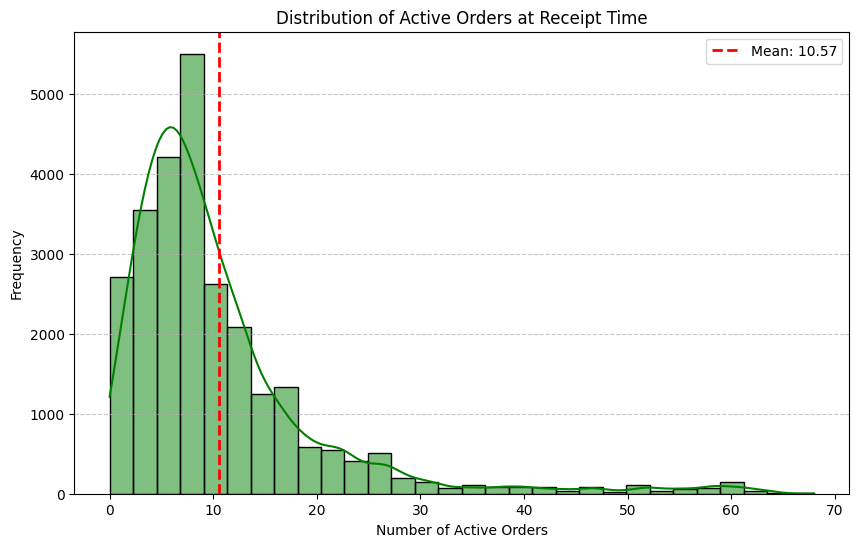

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(features['active_orders_at_receipt_time'], bins=30, kde=True, color='green')

plt.title('Distribution of Active Orders at Receipt Time')
plt.xlabel('Number of Active Orders')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding a vertical line for the mean
plt.axvline(features['active_orders_at_receipt_time'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {features['active_orders_at_receipt_time'].mean():.2f}")
plt.legend()

plt.show()

# Takeaway from this plot

- most deliveries are clustered around 0 to 20 band , with a long tail at 68
- highest activity is at 5 and 10 orders
- not a normal distribution , rather close to a poisson distribution

Missing trajectory correlates with:

- indoor deliveries

- dense urban regions

- courier behavior

- phone battery / device quality

- congestion

In [77]:
# making original feature dataset with columns having speed_mean as null i.e if gps was stale than 30 mins its null
# if gps is not available we want the model to learn to
features = features.with_columns(
    pl.col("speed_mean")
      .is_not_null()
      .cast(pl.Int8)
      .alias("is_trajectory_available")
)

In [78]:
# structural fill as imputation

features = features.with_columns([
    pl.col("speed_mean").fill_null(0),
    pl.col("distance_travelled").fill_null(0),
    pl.col("gps_points").fill_null(0)
])


# 0 = no observed motion
# indicator explains why

THe idea here is to have Bandit learn two policies:

if GPS available → trajectory policy
if GPS missing   → workload/time policy

Without indicator , the model confuses absence with slow movement.

This 'structural fill' prevents the model from crashing on nulls while preserving the knowledge that 'missing' is a distinct operational state from 'stationary'.

In [79]:
# testing corr

features.select(
    pl.corr(
        "active_orders_at_receipt_time",
        "is_trajectory_available"
    )
)

active_orders_at_receipt_time
f64
-0.066676



ρ(workload, GPS available)≈−0.067

This is:

- very small magnitude

- slightly negative

- essentially near independence

thus GPS missingness is NOT strongly driven by courier workload.

missing GPS → confounded workload signal

which means trajectory signal and workload signal are complementary
- features add independent information
- contextual bandit will benefit from both

As workload increases, the likelihood of having fresh GPS data slightly decreases. This could be because very busy couriers are more likely to be deep inside buildings (where GPS drops) or their phones are under more resource strain.


a value of -0.06 is extremely close to zero. In statistics, this is considered negligible or near-independent.

---

In [80]:
# analyzes how courier workload (active orders) impacts delivery performance (ETA).

# groups all workloads of 20 or more into a single 'high-congestion' bucket.
# This prevents rare extreme values (like the max of 68) from making the analysis too noisy.
# For each workload level, it calculates the mean_eta (average delivery time) and n (the number of deliveries at that load).
# and orders the result by workload to reveal trends.

features.group_by(
    pl.col("active_orders_at_receipt_time").clip(upper_bound=20)
).agg(
    pl.mean("eta_mins").alias("mean_eta"),
    pl.len().alias("n")
).sort("active_orders_at_receipt_time")

active_orders_at_receipt_time,mean_eta,n
i32,f64,u32
0,190.863333,600
1,175.185185,837
2,232.119403,1273
3,190.290264,1664
4,209.953797,1883
…,…,…
16,316.237931,580
17,328.363636,429
18,347.309375,320


# takeawaays

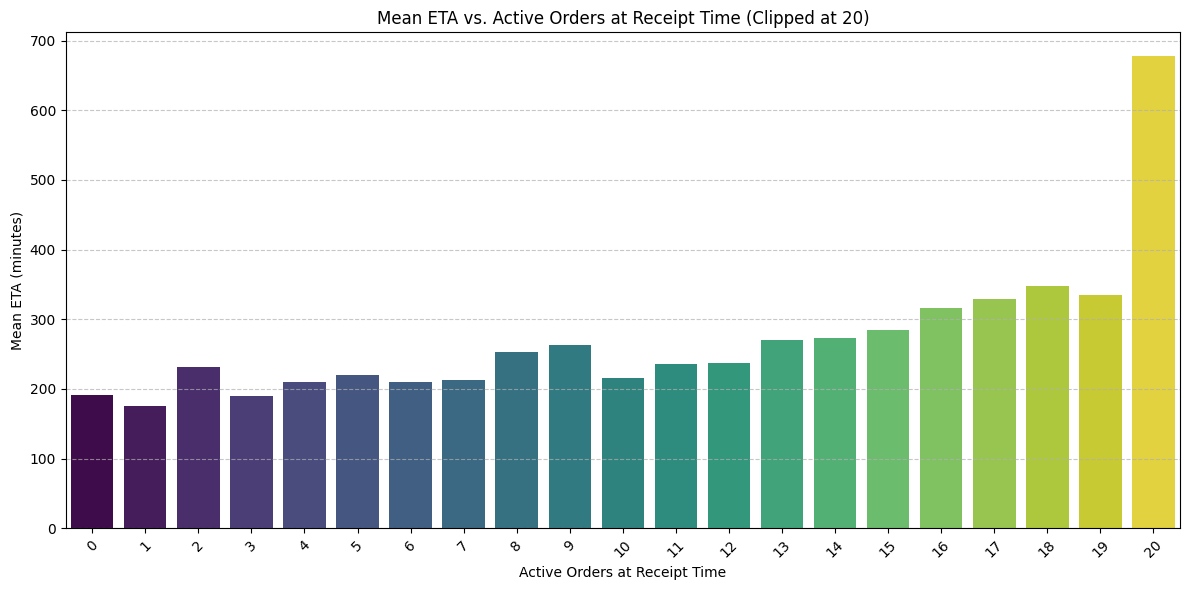

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create the aggregated DataFrame for plotting
plot_df = features.group_by(
    pl.col("active_orders_at_receipt_time").clip(upper_bound=20)
).agg(
    pl.mean("eta_mins").alias("mean_eta"),
    pl.len().alias("n")
).sort("active_orders_at_receipt_time").to_pandas()

plt.figure(figsize=(12, 6))
sns.barplot(x="active_orders_at_receipt_time", y="mean_eta", data=plot_df, palette="viridis", hue="active_orders_at_receipt_time", legend=False)
plt.title('Mean ETA vs. Active Orders at Receipt Time (Clipped at 20)')
plt.xlabel('Active Orders at Receipt Time')
plt.ylabel('Mean ETA (minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Low workload (0–4)
ETA ≈ 175–230

Noise dominates. Couriers still flexible.

Medium workload (5–15)

ETA trends upward slowly.

This reflects:

route consolidation phase


High workload (>15)

ETA increases strongly.

This is queue saturation.

Extreme workload (=20 bucket)
ETA ≈ 678
n = 3078 (very large!)

20 = ALL workloads ≥ 20

aggregates till 20,21,22,...68

This shape matches queueing theory

In M/G/1 queue models:

𝑊
∝
𝜌
1
−
𝜌
W∝
1−ρ
ρ
	​


Delay explodes near saturation.

The bar chart perfectly illustrates the Saturation Curve we discussed.

The Plateau (0-10 orders): You can see that the bars for low workloads are relatively similar in height. This suggests that in this range, the courier system is efficient and can handle 'one more order' without a significant penalty.
The Inflection Point (15+ orders): Notice how the bars start stepping up more noticeably after the workload passes 15. This is the transition into a 'congested' state.
The Saturation Spike (20+ bucket): The final bar (representing all workloads ≥ 20) is significantly taller than the rest, jumping to over 600 minutes.

: This confirms that the 'cost' of an additional order is non-linear. This justifies adding non-linear features like high_load or overloaded indicators to help your bandit model distinguish between a 'busy' courier and an 'overwhelmed' one.

---
need to add non-linear workload features


In [82]:
# groups orders to prevent model from overreacting to rare outliers like 68

# - cap on 20 - based on the bar chart above
# high load if active orders > 10
# overloaded if active orders > 15
features = features.with_columns([
    pl.col("active_orders_at_receipt_time")
        .clip(upper_bound=20)
        .alias("workload_capped"),

    (pl.col("active_orders_at_receipt_time") > 10)
        .cast(pl.Int8)
        .alias("high_load"),

    (pl.col("active_orders_at_receipt_time") > 15)
        .cast(pl.Int8)
        .alias("overloaded")
])

In [83]:
features.head()

order_id,from_dipan_id,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,ds,from_city_en,eta_mins,pickup_destination_distance,batch_size,batch_rank,last_x,last_y,gps_gap_min,gps_points,speed_mean,distance_travelled,pickup_destination_distance_right,hour,weekday,delivery_sequence,is_weekend,is_holiday,is_holiday_eve,day_of_week,regime_type,hour_sin,hour_cos,day_sin,day_cos,active_orders_at_receipt_time,is_trajectory_available,workload_capped,high_load,overloaded
str,str,str,f64,f64,str,str,datetime[μs],f64,f64,datetime[μs],i64,str,f64,f64,u32,i64,f64,f64,i64,i64,f64,f64,f64,i8,i8,u32,bool,bool,bool,i8,str,f64,f64,f64,f64,i32,i8,i32,i8,i8
"""7b15e523a08ad352b9f22bb4ecd998…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9031e6,-7.6873e6,"""bfac06c1b710a20d8dcfb8d3093d7e…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:20:00,8.9041e6,-7.6866e6,2021-03-18 11:51:00,318,"""Chongqing""",211.0,1247.315938,1,0,null,null,null,0,0.0,0.0,1247.315938,8,4,1,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,0,0,0,0,0
"""3d7ca50514737df23244a2c633b7ee…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9035e6,-7.6870e6,"""8ceca456f58ab1d2595d571a2205c5…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 11:26:00,318,"""Chongqing""",185.0,763.699221,3,0,null,null,null,0,0.0,0.0,763.699221,8,4,2,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0
"""5134623a6ae48bf37cc58bbcb22412…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9028e6,-7.6875e6,"""8b8a66982b68f85ed1d8e56dfe3144…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:19:00,318,"""Chongqing""",598.0,1568.190039,3,1,null,null,null,0,0.0,0.0,1568.190039,8,4,3,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0
"""95334065d9951e356138196715ba21…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9032e6,-7.6870e6,"""35ba604f0afd85d280cb9d96a69874…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:33:00,318,"""Chongqing""",612.0,1007.927018,3,2,null,null,null,0,0.0,0.0,1007.927018,8,4,4,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0
"""4767aafe217550daac5895cbc46b46…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9030e6,-7.6871e6,"""594c43284e8d7dedd4fcf06106379f…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:23:00,8.9041e6,-7.6866e6,2021-03-18 12:18:00,318,"""Chongqing""",235.0,1273.960789,1,0,null,null,null,0,0.0,0.0,1273.960789,8,4,5,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,4,0,4,0,0


In [84]:

# Identify pairs
duplicate_pairs = [(c.replace('_right', ''), c) for c in features.columns if c.endswith('_right')]

for original, duplicate in duplicate_pairs:
    if original in features.columns:
        # Check if all non-null values are identical
        mismatches = features.filter(pl.col(original) != pl.col(duplicate)).height
        if mismatches == 0:
            print(f"Validation Passed: '{original}' and '{duplicate}' are identical. Safe to drop.")
        else:
            print(f"Validation FAILED: '{original}' and '{duplicate}' have {mismatches} mismatches!")
    else:
        print(f"Original column '{original}' not found for duplicate '{duplicate}'")

Validation Passed: 'pickup_destination_distance' and 'pickup_destination_distance_right' are identical. Safe to drop.


---

Testing if we should use batch ranking as feature - state representation designing .
Batch rank matters only if multiple orders accepted at SAME timestamp i.e. dispatcher pushes a batch simultaneously.

output was 5578 rows with duplicate receipt_time per courier
counts up to 12

This means :

- t0: +12 orders instantly
- t1: +8 orders instantly
- t2: +6 orders instantly
...


with rank batch ,

first package in batch
vs
last package in batch



In [85]:
# diagonistic step to check if batching actually happens in the dataset
delivery.group_by(
    ["delivery_user_id", "receipt_time"]
).count().filter(pl.col("count") > 1)

/tmp/ipykernel_461/674322898.py:4: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  ).count().filter(pl.col("count") > 1)


delivery_user_id,receipt_time,count
str,datetime[μs],u32
"""09a6e60d6663087288b8d257d6632e…",2021-03-25 08:31:00,4
"""4ed9e93fc8b17c89d789a9ee6e51c5…",2021-03-20 08:14:00,3
"""53aad53ab7c4c35e9b7c26a5431906…",2021-03-20 14:50:00,4
"""7fbaebc309ff50193ffc64327d15cc…",2021-03-28 08:37:00,2
"""0c032cafea40c06fa6337701caf356…",2021-03-19 07:39:00,3
…,…,…
"""a7bd80d42f50239793fff18f350921…",2021-03-27 14:54:00,2
"""a22a548fee5669dec34ad0d02a8669…",2021-03-27 15:00:00,3
"""a7b7d763a685429818fdfdf5767361…",2021-03-22 14:23:00,2


Adding ordinal rank batching

In [86]:
features.select([
    pl.corr("batch_rank","eta_mins"),
    pl.corr("workload_capped","eta_mins"),
    pl.corr("speed_mean","eta_mins")
])

batch_rank,workload_capped,speed_mean
f64,f64,f64
0.16645,0.154929,-0.037711


# takeaways on the correlation  values

- Rank Dominance (0.166): The positive correlation for batch_rank confirms that the sequence matters. As the rank increases (e.g., from 1st to 10th in a batch), the ETA consistently goes up. This is likely because the courier delivers orders in a specific sequence, and later ranks must wait for earlier deliveries to finish.

- Workload Impact (0.155): The positive correlation for workload_capped confirms that total system pressure is a key driver of delay. As a courier takes on more concurrent orders, the delivery time for any single order tends to increase.

- Mobility Weakness (-0.038): The very small negative correlation for speed_mean suggests that while faster movement slightly reduces ETA, the 'static' state (how many orders you have and where you are in the queue) is a much stronger predictor than 'dynamic' speed.

---

Contextual Bandit should prioritize these 'queue-based' features over 'mobility-based' ones for accurate ETA prediction


Interpretation for batch_size

Feature	Meaning
- batch_size ->	how many orders accepted together
- batch_rank ->	position inside batch
- active_orders ->	total workload

Idea is to have model learn ETA increases ↑ if:
    workload high
    AND rank late in batch


Source : deepETA paper implicitly models this via route order embeddings.

Key references

Li et al., KDD 2018 — DeepETA

Ke et al., KDD 2017 — ETA Prediction for Logistics

Chen et al., SIGSPATIAL 2021 — Learning to Route

Zhang et al., WWW 2020 — Courier Dispatching

In [87]:
features.select([
    pl.corr("batch_rank","eta_mins"),
    pl.corr("workload_capped","eta_mins"),
    pl.corr("speed_mean","eta_mins"),
    pl.corr("gps_gap_min","eta_mins")
])

batch_rank,workload_capped,speed_mean,gps_gap_min
f64,f64,f64,f64
0.16645,0.154929,-0.037711,-0.004935


Strongest Predictors (batch_rank: 0.166 & workload_capped: 0.155): These positive correlations confirm that the courier's current queue is the primary driver of delay. As their rank in a batch or their total workload increases, the delivery time grows significantly. This is the 'queueing physics' of the system.

Weak Predictor (speed_mean: -0.038): The small negative value suggests that while moving faster helps, it's a minor factor compared to the number of stops the courier has to make.

Negligible Predictor (gps_gap_min: -0.005): This value is effectively zero. It tells us that the 'freshness' of the GPS data itself doesn't directly cause a delivery to be faster or slower.

---

checking the rank and batching

In [88]:
delivery.select([
    pl.max("batch_size"),
    pl.max("batch_rank")
])

batch_size,batch_rank
u32,i64
42,41


In [89]:
# sanity_check

delivery.filter(pl.col("batch_size") == 42)\
.select([
    "receipt_time",
    "order_id",
    "batch_rank"
]).head(50)

receipt_time,order_id,batch_rank
datetime[μs],str,i64
2021-03-24 08:54:00,"""06af1ca8ea57e12f13c2cc3a437659…",0
2021-03-24 08:54:00,"""0e60df1a156818528460210b6dedc8…",1
2021-03-24 08:54:00,"""106051925cccefedc87115222ae545…",2
2021-03-24 08:54:00,"""17ce04f0557edec63405bbb55a3de6…",3
2021-03-24 08:54:00,"""201ab1aa23f46d0ef139408c97300c…",4
…,…,…
2021-03-24 08:54:00,"""e89a7ff413b71af71229419552f762…",37
2021-03-24 08:54:00,"""ef6ff756efcec993db71247856307d…",38
2021-03-24 08:54:00,"""f0be5192a034ce4f38591baa0065c4…",39


In [90]:
features.select(
    pl.corr("batch_rank","eta_mins")
)

batch_rank
f64
0.16645


ETA is influenced by multiple independent mechanisms:

ETA=f(route)+f(batch position)+f(workload)+f(traffic)+ϵ

Batch position explains one component, not all variance.

So moderate correlation is expected.
dispatch batching behaves nonlinearly.Within a batch: rank 1 → small delay
rank middle → moderate delay
rank last → large delay

In [91]:
# validation

features.group_by(
    pl.col("batch_rank").clip(upper_bound=15)
).agg(
    pl.mean("eta_mins").alias("mean_eta"),
    pl.len().alias("n")
).sort("batch_rank")

batch_rank,mean_eta,n
i64,f64,u32
0,238.005531,9583
1,264.057548,5578
2,284.730188,3773
3,255.220618,2493
4,268.986069,1651
…,…,…
11,352.412281,114
12,485.0,81
13,570.044118,68


Early batch (0–4)

ETA increases gradually:

238 → 285

---
Mid batch (5–10)

ETA steadily increases.

---

DElay explodes at last batch

dispatcher assigns large batch
↓
courier executes route sequentially
↓
last orders wait for entire route

In [92]:
# adding capped features

features = features.with_columns([
    pl.col("batch_rank").clip(upper_bound=15).alias("batch_rank_capped"),

    (pl.col("batch_rank") > 8)
        .cast(pl.Int8)
        .alias("late_batch"),

    (pl.col("batch_rank") > 12)
        .cast(pl.Int8)
        .alias("extreme_batch")
])

Batch rank is acting as a proxy for route position.

# Curent validation

subsystem	validated by
trajectory=	CCDF analysis
workload =	nonlinear ETA curve
batching =	monotonic rank curve
missingness =	independence check

This is a complete courier-state representation.

In [93]:
# This code evaluates how being in a 'late' position
# within a batch (specifically, rank 8 or higher) impacts delivery performance.
features.select([
    "late_batch",
    "eta_mins"
]).group_by("late_batch").agg([
    pl.mean("eta_mins").alias("eta_mean"),
    pl.std("eta_mins").alias("eta_std"),
])

late_batch,eta_mean,eta_std
i8,f64,f64
0,264.350289,674.861819
1,777.599628,1813.825481


eta_mean for late batches (778 mins) is nearly 3 times higher than for early batches (264 mins). Even more importantly, the eta_std explodes from 675 to 1,814. This implies to Contextual Bandit that late-rank orders are not just slower, they are significantly more unpredictable, which is a critical signal for risk-aware routing or pricing.

Mean ETA Explosion: For 'normal' orders (late_batch = 0), the average delivery time is ~264 minutes. For late-rank orders (late_batch = 1), it jumps to ~778 minutes—nearly 3 times longer. This validates that the courier's queue is the main bottleneck.

Uncertainty Risk (Standard Deviation): The eta_std for late batches (1813.8) is almost 2.7 times higher than for early ones. This means late-rank orders aren't just slower; they are much harder to predict accurately.

This proves that a 'Late Batch' state is fundamentally different from a 'Normal' state. Your reward function in the Contextual Bandit should likely penalize prediction errors more heavily in these high-variance 'Late Batch' scenarios, as they represent the highest risk to customer satisfaction.


In [94]:
print(features.schema)

Schema({'order_id': String, 'from_dipan_id': String, 'delivery_user_id': String, 'poi_lng': Float64, 'poi_lat': Float64, 'aoi_id': String, 'typecode': String, 'receipt_time': Datetime(time_unit='us', time_zone=None), 'receipt_lng': Float64, 'receipt_lat': Float64, 'sign_time': Datetime(time_unit='us', time_zone=None), 'ds': Int64, 'from_city_en': String, 'eta_mins': Float64, 'pickup_destination_distance': Float64, 'batch_size': UInt32, 'batch_rank': Int64, 'last_x': Float64, 'last_y': Float64, 'gps_gap_min': Int64, 'gps_points': Int64, 'speed_mean': Float64, 'distance_travelled': Float64, 'pickup_destination_distance_right': Float64, 'hour': Int8, 'weekday': Int8, 'delivery_sequence': UInt32, 'is_weekend': Boolean, 'is_holiday': Boolean, 'is_holiday_eve': Boolean, 'day_of_week': Int8, 'regime_type': String, 'hour_sin': Float64, 'hour_cos': Float64, 'day_sin': Float64, 'day_cos': Float64, 'active_orders_at_receipt_time': Int32, 'is_trajectory_available': Int8, 'workload_capped': Int32, 

In [95]:
features.lazy().explain()


'DF ["order_id", "from_dipan_id", "delivery_user_id", "poi_lng", ...]; PROJECT */44 COLUMNS'

computed:
E[ETA∣late_batch]andVar(ETA∣late_batch)

This is essentially measuring state-dependent uncertainty.

In normal dispatch , mean ETA ≈ 264 , std  ≈ 675
in late dispatch , mean ETA ≈ 778   (≈ 3× larger) , std  ≈ 1814      (≈ 2.7× larger)



Unsupervised regression assumes:

- Var(ϵ∣X)≈const


The data shows:


Var(ϵ∣state) changes drastically

This is heteroscedasticity driven by operational state.

Late batches are fundamentally less predictable.

Points for reward design :

reward = - abs(pred_eta - true_eta) / (1 + workload_capped)

---
What works
-----------------------------------
- latent variable |	proxy feature
-----------------------------
- route position |	batch_rank
- queue pressure |	workload
- mobility state |	speed_mean
- uncertainty regime |	late_batch

In [96]:
# final sanity check with unique aliases to avoid DuplicateError

features.select([
    pl.corr("batch_rank", "workload_capped").alias("corr_rank_workload"),
    pl.corr("batch_rank", "late_batch").alias("corr_rank_late"),
    pl.corr("workload_capped", "late_batch").alias("corr_workload_late")
])

corr_rank_workload,corr_rank_late,corr_workload_late
f64,f64,f64
0.383481,0.743454,0.302546


This sanity check provides a clear look at how your 'Queue' features relate to one another:

- Rank vs. Late Batch (0.74): This high positive correlation is expected. Since late_batch is a binary indicator triggered at batch_rank 8, they are mathematically linked. However, the fact that it isn't 1.0 is good—it means the indicator correctly isolates the 'tail' of the distribution from the continuous rank.

- Rank vs. Workload (0.38): This moderate correlation is very insightful. It shows that as total workload increases, couriers also tend to receive larger individual batches. They move together, but one doesn't dictate the other, meaning both columns add unique information to your model.

- Workload vs. Late Batch (0.30): Similar to the above, this shows that being in a 'late' position often coincides with high overall pressure, but not always. You could have a late rank in a small batch even if the overall workload is low.

Conclusion: These features are 'complementary.' They aren't so highly correlated that they cause redundancy (multicollinearity), but they are logically connected in a way that helps the Contextual Bandit understand different levels of operational stress.



In [97]:
features.head()

order_id,from_dipan_id,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,ds,from_city_en,eta_mins,pickup_destination_distance,batch_size,batch_rank,last_x,last_y,gps_gap_min,gps_points,speed_mean,distance_travelled,pickup_destination_distance_right,hour,weekday,delivery_sequence,is_weekend,is_holiday,is_holiday_eve,day_of_week,regime_type,hour_sin,hour_cos,day_sin,day_cos,active_orders_at_receipt_time,is_trajectory_available,workload_capped,high_load,overloaded,batch_rank_capped,late_batch,extreme_batch
str,str,str,f64,f64,str,str,datetime[μs],f64,f64,datetime[μs],i64,str,f64,f64,u32,i64,f64,f64,i64,i64,f64,f64,f64,i8,i8,u32,bool,bool,bool,i8,str,f64,f64,f64,f64,i32,i8,i32,i8,i8,i64,i8,i8
"""7b15e523a08ad352b9f22bb4ecd998…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9031e6,-7.6873e6,"""bfac06c1b710a20d8dcfb8d3093d7e…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:20:00,8.9041e6,-7.6866e6,2021-03-18 11:51:00,318,"""Chongqing""",211.0,1247.315938,1,0,null,null,null,0,0.0,0.0,1247.315938,8,4,1,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,0,0,0,0,0,0,0,0
"""3d7ca50514737df23244a2c633b7ee…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9035e6,-7.6870e6,"""8ceca456f58ab1d2595d571a2205c5…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 11:26:00,318,"""Chongqing""",185.0,763.699221,3,0,null,null,null,0,0.0,0.0,763.699221,8,4,2,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0,0,0,0
"""5134623a6ae48bf37cc58bbcb22412…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9028e6,-7.6875e6,"""8b8a66982b68f85ed1d8e56dfe3144…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:19:00,318,"""Chongqing""",598.0,1568.190039,3,1,null,null,null,0,0.0,0.0,1568.190039,8,4,3,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0,1,0,0
"""95334065d9951e356138196715ba21…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9032e6,-7.6870e6,"""35ba604f0afd85d280cb9d96a69874…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:33:00,318,"""Chongqing""",612.0,1007.927018,3,2,null,null,null,0,0.0,0.0,1007.927018,8,4,4,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0,2,0,0
"""4767aafe217550daac5895cbc46b46…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9030e6,-7.6871e6,"""594c43284e8d7dedd4fcf06106379f…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:23:00,8.9041e6,-7.6866e6,2021-03-18 12:18:00,318,"""Chongqing""",235.0,1273.960789,1,0,null,null,null,0,0.0,0.0,1273.960789,8,4,5,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,4,0,4,0,0,0,0,0


In [98]:

# List all columns to verify completeness
print(f"Total columns: {len(features.columns)}")
print("--- Column List ---")
for col in sorted(features.columns):
    print(f"- {col}")

# Check for any remaining nulls in critical predictors
null_summary = features.select([
    pl.col("active_orders_at_receipt_time").null_count().alias("null_workload"),
    pl.col("batch_rank").null_count().alias("null_rank"),
    pl.col("speed_mean").null_count().alias("null_speed")
])

display(null_summary)

Total columns: 44
--- Column List ---
- active_orders_at_receipt_time
- aoi_id
- batch_rank
- batch_rank_capped
- batch_size
- day_cos
- day_of_week
- day_sin
- delivery_sequence
- delivery_user_id
- distance_travelled
- ds
- eta_mins
- extreme_batch
- from_city_en
- from_dipan_id
- gps_gap_min
- gps_points
- high_load
- hour
- hour_cos
- hour_sin
- is_holiday
- is_holiday_eve
- is_trajectory_available
- is_weekend
- last_x
- last_y
- late_batch
- order_id
- overloaded
- pickup_destination_distance
- pickup_destination_distance_right
- poi_lat
- poi_lng
- receipt_lat
- receipt_lng
- receipt_time
- regime_type
- sign_time
- speed_mean
- typecode
- weekday
- workload_capped


null_workload,null_rank,null_speed
u32,u32,u32
0,0,0


In [99]:
# SANITY CHECK FINAL

# 1. Target check
null_target = features.select(pl.col("eta_mins").null_count()).item()

# 2. Key uniqueness check
total_rows = features.height
unique_orders = features.select(pl.col("order_id").n_unique()).item()

# 3. Duplicate name check
duplicates = [c for c in features.columns if "_right" in c]

print(f"Null targets: {null_target}")
print(f"Row count vs Unique Order IDs: {total_rows} vs {unique_orders}")
if duplicates:
    print(f"Warning: Duplicate columns found: {duplicates}")
else:
    print("No duplicate columns detected.")

# 4. Final preview of the feature vector
display(features.head())

Null targets: 0
Row count vs Unique Order IDs: 26670 vs 26670


order_id,from_dipan_id,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,ds,from_city_en,eta_mins,pickup_destination_distance,batch_size,batch_rank,last_x,last_y,gps_gap_min,gps_points,speed_mean,distance_travelled,pickup_destination_distance_right,hour,weekday,delivery_sequence,is_weekend,is_holiday,is_holiday_eve,day_of_week,regime_type,hour_sin,hour_cos,day_sin,day_cos,active_orders_at_receipt_time,is_trajectory_available,workload_capped,high_load,overloaded,batch_rank_capped,late_batch,extreme_batch
str,str,str,f64,f64,str,str,datetime[μs],f64,f64,datetime[μs],i64,str,f64,f64,u32,i64,f64,f64,i64,i64,f64,f64,f64,i8,i8,u32,bool,bool,bool,i8,str,f64,f64,f64,f64,i32,i8,i32,i8,i8,i64,i8,i8
"""7b15e523a08ad352b9f22bb4ecd998…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9031e6,-7.6873e6,"""bfac06c1b710a20d8dcfb8d3093d7e…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:20:00,8.9041e6,-7.6866e6,2021-03-18 11:51:00,318,"""Chongqing""",211.0,1247.315938,1,0,null,null,null,0,0.0,0.0,1247.315938,8,4,1,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,0,0,0,0,0,0,0,0
"""3d7ca50514737df23244a2c633b7ee…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9035e6,-7.6870e6,"""8ceca456f58ab1d2595d571a2205c5…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 11:26:00,318,"""Chongqing""",185.0,763.699221,3,0,null,null,null,0,0.0,0.0,763.699221,8,4,2,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0,0,0,0
"""5134623a6ae48bf37cc58bbcb22412…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9028e6,-7.6875e6,"""8b8a66982b68f85ed1d8e56dfe3144…","""73ffcbd1b26557b462b14e4dd4c57f…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:19:00,318,"""Chongqing""",598.0,1568.190039,3,1,null,null,null,0,0.0,0.0,1568.190039,8,4,3,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0,1,0,0
"""95334065d9951e356138196715ba21…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9032e6,-7.6870e6,"""35ba604f0afd85d280cb9d96a69874…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:21:00,8.9041e6,-7.6866e6,2021-03-18 18:33:00,318,"""Chongqing""",612.0,1007.927018,3,2,null,null,null,0,0.0,0.0,1007.927018,8,4,4,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,3,0,3,0,0,2,0,0
"""4767aafe217550daac5895cbc46b46…","""37e976ad4abb10da92c97c6b34f7f5…","""0008c2b6a2314db8715301b7eeeebc…",8.9030e6,-7.6871e6,"""594c43284e8d7dedd4fcf06106379f…","""203ac3454d75e02ebb0a3c6f51d735…",2021-03-18 08:23:00,8.9041e6,-7.6866e6,2021-03-18 12:18:00,318,"""Chongqing""",235.0,1273.960789,1,0,null,null,null,0,0.0,0.0,1273.960789,8,4,5,false,false,false,4,"""Weekday""",0.866025,-0.5,-0.433884,-0.900969,4,0,4,0,0,0,0,0


# Weather section

In [100]:


weather = (
    pl.read_csv("/content/drive/MyDrive/ml/weather-outputs/chongqing_wsi_mar17_apr20_2021.csv")
    .with_columns([
        pl.col("datetime")
          .str.strptime(pl.Datetime, strict=False)
          .alias("weather_time")
    ])
    .drop("datetime")
)

In [101]:
weather.schema

Schema([('city', String),
        ('temperature_2m', Float64),
        ('precipitation', Float64),
        ('rain', Float64),
        ('weathercode', Int64),
        ('windspeed_10m', Float64),
        ('norm_temperature_dev', Float64),
        ('norm_precipitation', Float64),
        ('norm_windspeed', Float64),
        ('norm_weathercode_sev', Float64),
        ('WSI', Float64),
        ('weather_time', Datetime(time_unit='us', time_zone=None))])

In [102]:
import polars as pl

city_weather = weather.filter(pl.col('city') == CITY_IN_QUES)
city_weather = city_weather.sort('weather_time')

# 3. Verify the output
print('CITY Weather DataFrame (head 5):')
print(city_weather.head(5))

CITY Weather DataFrame (head 5):
shape: (5, 12)
┌───────────┬─────────────┬─────────────┬──────┬───┬────────────┬────────────┬────────┬────────────┐
│ city      ┆ temperature ┆ precipitati ┆ rain ┆ … ┆ norm_winds ┆ norm_weath ┆ WSI    ┆ weather_ti │
│ ---       ┆ _2m         ┆ on          ┆ ---  ┆   ┆ peed       ┆ ercode_sev ┆ ---    ┆ me         │
│ str       ┆ ---         ┆ ---         ┆ f64  ┆   ┆ ---        ┆ ---        ┆ f64    ┆ ---        │
│           ┆ f64         ┆ f64         ┆      ┆   ┆ f64        ┆ f64        ┆        ┆ datetime[μ │
│           ┆             ┆             ┆      ┆   ┆            ┆            ┆        ┆ s]         │
╞═══════════╪═════════════╪═════════════╪══════╪═══╪════════════╪════════════╪════════╪════════════╡
│ Chongqing ┆ 17.2        ┆ 0.0         ┆ 0.0  ┆ … ┆ 0.4471     ┆ 0.1111     ┆ 0.1801 ┆ 2021-03-17 │
│           ┆             ┆             ┆      ┆   ┆            ┆            ┆        ┆ 00:00:00   │
│ Chongqing ┆ 16.4        ┆ 0.0         ┆ 0

In [103]:

# 1. Ensure both dataframes are explicitly sorted on the join keys
features = features.sort("receipt_time")
city_weather = city_weather.sort("weather_time")

# 2. Perform temporal join_asof between features and city_weather
# match receipt_time with weather_time using 'backward' to get the latest weather report
features = features.join_asof(
    city_weather,
    left_on="receipt_time",
    right_on="weather_time",
    strategy="backward"
).drop("city")

# Verify join by checking nulls in critical weather columns
weather_validation = features.select([
    pl.col("WSI").null_count().alias("null_WSI"),
    pl.col("precipitation").null_count().alias("null_precip"),
    pl.len().alias("total_rows")
])

print("Weather Join Validation:")
print(weather_validation)

# 3. Final summary of the enriched dataset
print("\nEnriched Features Schema:")
print(features.schema)
print(f"\nFinal Row Count: {features.height}")

Weather Join Validation:
shape: (1, 3)
┌──────────┬─────────────┬────────────┐
│ null_WSI ┆ null_precip ┆ total_rows │
│ ---      ┆ ---         ┆ ---        │
│ u32      ┆ u32         ┆ u32        │
╞══════════╪═════════════╪════════════╡
│ 0        ┆ 0           ┆ 26670      │
└──────────┴─────────────┴────────────┘

Enriched Features Schema:
Schema({'order_id': String, 'from_dipan_id': String, 'delivery_user_id': String, 'poi_lng': Float64, 'poi_lat': Float64, 'aoi_id': String, 'typecode': String, 'receipt_time': Datetime(time_unit='us', time_zone=None), 'receipt_lng': Float64, 'receipt_lat': Float64, 'sign_time': Datetime(time_unit='us', time_zone=None), 'ds': Int64, 'from_city_en': String, 'eta_mins': Float64, 'pickup_destination_distance': Float64, 'batch_size': UInt32, 'batch_rank': Int64, 'last_x': Float64, 'last_y': Float64, 'gps_gap_min': Int64, 'gps_points': Int64, 'speed_mean': Float64, 'distance_travelled': Float64, 'pickup_destination_distance_right': Float64, 'hour': Int8

In [104]:
import polars as pl

# 1. Calculate percentage of nulls for WSI or precipitation
null_stats = features.select([
    (pl.col('WSI').null_count() / pl.len() * 100).alias('pct_missing_WSI'),
    (pl.col('precipitation').null_count() / pl.len() * 100).alias('pct_missing_precip')
])
print('Missing Weather Data Coverage:')
print(null_stats)

# 2. Describe distribution of key weather columns
weather_cols = ['temperature_2m', 'precipitation', 'WSI', 'windspeed_10m', 'norm_weathercode_sev']
print('\nWeather Distribution Summary:')
print(features.select(weather_cols).describe())

# 3. Identify date range of missing weather data
missing_weather_range = features.filter(pl.col('WSI').is_null()).select([
    pl.col('receipt_time').min().alias('missing_start'),
    pl.col('receipt_time').max().alias('missing_end'),
    pl.len().alias('missing_count')
])

print('\nDate Range for Missing Weather Data:')
print(missing_weather_range)

# Compare with earliest available weather data to confirm 'backward' join logic implications
print('\nEarliest available weather report time:')
print(city_weather.select(pl.col('weather_time').min()).item())

Missing Weather Data Coverage:
shape: (1, 2)
┌─────────────────┬────────────────────┐
│ pct_missing_WSI ┆ pct_missing_precip │
│ ---             ┆ ---                │
│ f64             ┆ f64                │
╞═════════════════╪════════════════════╡
│ 0.0             ┆ 0.0                │
└─────────────────┴────────────────────┘

Weather Distribution Summary:
shape: (9, 6)
┌────────────┬────────────────┬───────────────┬──────────┬───────────────┬──────────────────────┐
│ statistic  ┆ temperature_2m ┆ precipitation ┆ WSI      ┆ windspeed_10m ┆ norm_weathercode_sev │
│ ---        ┆ ---            ┆ ---           ┆ ---      ┆ ---           ┆ ---                  │
│ str        ┆ f64            ┆ f64           ┆ f64      ┆ f64           ┆ f64                  │
╞════════════╪════════════════╪═══════════════╪══════════╪═══════════════╪══════════════════════╡
│ count      ┆ 26670.0        ┆ 26670.0       ┆ 26670.0  ┆ 26670.0       ┆ 26670.0              │
│ null_count ┆ 0.0            ┆ 0.0

In [105]:
features.select([ pl.corr("hour", "eta_mins").alias("corr_hour_eta"),
                 pl.corr("weekday", "eta_mins").alias("corr_weekday_eta"),
                  pl.corr("hour_sin", "eta_mins").alias("corr_hour_sin_eta"),
                  pl.corr("hour_cos", "eta_mins").alias("corr_hour_cos_eta"),
                  pl.corr("day_sin", "eta_mins").alias("corr_day_sin_eta"),
                  pl.corr("day_cos", "eta_mins").alias("corr_day_cos_eta"),
                  pl.corr("hour", "workload_capped").alias("corr_hour_workload"),
                  pl.corr("weekday", "workload_capped").alias("corr_weekday_workload"),
                  pl.corr("hour_sin", "workload_capped").alias("corr_hour_sin_workload"),
                  pl.corr("hour_cos", "workload_capped").alias("corr_hour_cos_workload"),
                  pl.corr("day_sin", "workload_capped").alias("corr_day_sin_workload"),
                  pl.corr("day_cos", "workload_capped").alias("corr_day_cos_workload")
                ])

corr_hour_eta,corr_weekday_eta,corr_hour_sin_eta,corr_hour_cos_eta,corr_day_sin_eta,corr_day_cos_eta,corr_hour_workload,corr_weekday_workload,corr_hour_sin_workload,corr_hour_cos_workload,corr_day_sin_workload,corr_day_cos_workload
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.085667,0.004023,0.087009,0.052955,-0.001987,0.009584,-0.051338,0.03456,0.052484,-0.045193,-0.022943,0.035782


WSI doesn't have a strong linear relationship with ETA or courier workload,

---

managing typecode

The feature was processed using two distinct methods:
1.  **Grouping and One-Hot Encoding**: The 16 unique values were reduced to 4 distinct groups (the top 3 most frequent codes plus a "Rare" category). These were then converted into binary dummy variables to serve as root nodes for causal analysis.
2.  **Frequency Encoding**: A new numerical column, `typecode_cb`, was created by mapping each original code to its occurrence count (frequency) to provide a dense signal for contextual bandit models.

In [106]:
# typecode handling

# 1. Count occurrences and identify top codes
typecode_counts = features.select(pl.col("typecode").value_counts(sort=True)).unnest("typecode")
top_typecodes = typecode_counts.head(3).get_column("typecode").to_list()

# 2. Create a mapping for readable names
# type 1, 2, 3 for top codes, 'rare' for the rest (including nulls)
mapping = {code: f"type {i+1}" for i, code in enumerate(top_typecodes)}

# 3. Apply grouping with new labels
# map_elements handles mapping; any value not in top_typecodes (including None) defaults to 'rare'
features = features.with_columns(
    pl.col("typecode").map_elements(lambda x: mapping.get(x, "rare"), return_dtype=pl.Utf8)
    .alias("typecode_grouped")
)

# 4. Generate one-hot encoded binary columns with readable names
dummies = features.select("typecode_grouped").to_dummies("typecode_grouped")

# 5. Drop old dummy columns if they exist to avoid duplicates, then concat
features = features.drop([c for c in features.columns if "typecode_grouped_" in c])
features = pl.concat([features, dummies], how="horizontal")

# 6. Verification
print("Value counts of renamed grouped typecodes (Nulls merged into Rare):")
print(features.get_column("typecode_grouped").value_counts())

print("\nPreview of renamed dummy columns:")
dummy_cols = [c for c in features.columns if "typecode_grouped_" in c]
display(features.select(["order_id", "typecode_grouped"] + dummy_cols).head())

Value counts of renamed grouped typecodes (Nulls merged into Rare):
shape: (5, 2)
┌──────────────────┬───────┐
│ typecode_grouped ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ type 3           ┆ 1159  │
│ null             ┆ 26    │
│ rare             ┆ 2124  │
│ type 1           ┆ 16869 │
│ type 2           ┆ 6492  │
└──────────────────┴───────┘

Preview of renamed dummy columns:


order_id,typecode_grouped,typecode_grouped_null,typecode_grouped_rare,typecode_grouped_type 1,typecode_grouped_type 2,typecode_grouped_type 3
str,str,u8,u8,u8,u8,u8
"""e1a1e8c7528bade2d4bd94aacb939b…","""type 1""",0,0,1,0,0
"""f0d3cfce1bb22b2e0599abd1303371…","""rare""",0,1,0,0,0
"""5e78c5adc68c9b5a11105ab30aae74…","""type 2""",0,0,0,1,0
"""d19b5b563e38322095daad71406c4b…","""type 3""",0,0,0,0,1
"""5b88112323ae00346c3099867988c1…","""type 2""",0,0,0,1,0


In [107]:
# frequency_encoding

# 1. Map each typecode to its frequency (count) in the dataset
typecode_freq = features.group_by('typecode').len().rename({'len': 'typecode_cb'})

# 2. Join the frequency back to the features dataframe
features = features.join(typecode_freq, on='typecode', how='left')

# 3. Handle potential nulls in typecode (though rare) by filling with 0 if necessary
features = features.with_columns(pl.col('typecode_cb').fill_null(0))

print('Frequency encoding for typecode (typecode_cb) added.')
print(features.select(['order_id', 'typecode', 'typecode_cb']).head())

# 4. Verify distribution statistics
print('\\nDescriptive statistics for typecode_cb:')
print(features.select('typecode_cb').describe())

Frequency encoding for typecode (typecode_cb) added.
shape: (5, 3)
┌─────────────────────────────────┬─────────────────────────────────┬─────────────┐
│ order_id                        ┆ typecode                        ┆ typecode_cb │
│ ---                             ┆ ---                             ┆ ---         │
│ str                             ┆ str                             ┆ u32         │
╞═════════════════════════════════╪═════════════════════════════════╪═════════════╡
│ e1a1e8c7528bade2d4bd94aacb939b… ┆ 203ac3454d75e02ebb0a3c6f51d735… ┆ 16869       │
│ f0d3cfce1bb22b2e0599abd1303371… ┆ 37b081598a86e85e8887b0539ab618… ┆ 119         │
│ 5e78c5adc68c9b5a11105ab30aae74… ┆ fe76dff35bb199cdb7329eba2b918f… ┆ 6492        │
│ d19b5b563e38322095daad71406c4b… ┆ 14cca3f2714c7c0faf2cbac10ba12d… ┆ 1159        │
│ 5b88112323ae00346c3099867988c1… ┆ fe76dff35bb199cdb7329eba2b918f… ┆ 6492        │
└─────────────────────────────────┴─────────────────────────────────┴─────────────┘
\nDescrip

---

ETA in delivery systems is fundamentally a spatial process. Without spatial context, the model cannot distinguish between two deliveries that have identical workload, batch rank, and weather but occur in very different geographic environments

reference : Google ETA prediction (Ke et al., SIGKDD 2017)
Uses grid-based spatial congestion.

# Spatial Congestion index

Define spatial cell g and time window t.

SCI(g,t)=number of deliveries in spatial cell g during time window t

This becomes a spatial load indicator.


In [108]:
GRID_SIZE = 500

features = features.with_columns([
    (pl.col("receipt_lng") // GRID_SIZE).alias("grid_x"),
    (pl.col("receipt_lat") // GRID_SIZE).alias("grid_y")
])


# hourly time window

features = features.with_columns(
    pl.col("receipt_time").dt.truncate("1h").alias("time_window")
)

# spi calculation
spatial_congestion = (
    features
    .group_by(["grid_x","grid_y","time_window"])
    .len()
    .rename({"len":"spatial_congestion_index"})
)


# add back

features = features.join(
    spatial_congestion,
    on=["grid_x","grid_y","time_window"],
    how="left"
)



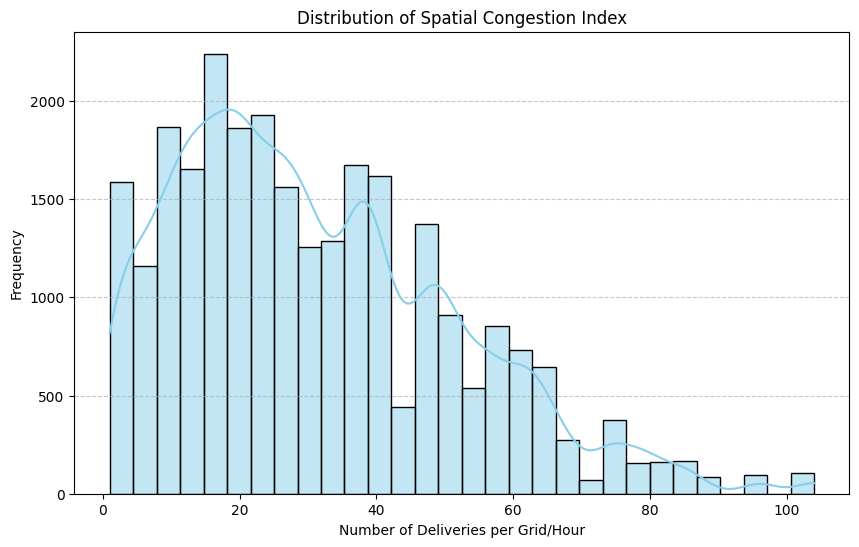

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(features['spatial_congestion_index'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Spatial Congestion Index')
plt.xlabel('Number of Deliveries per Grid/Hour')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [110]:
# courier level congestion calculation

courier_congestion = (
    features
    .group_by(["delivery_user_id","time_window"])
    .len()
    .rename({"len":"courier_local_load"})
)

features = features.join(
    courier_congestion,
    on=["delivery_user_id","time_window"],
    how="left"
)


# normalise spatial features

features = features.with_columns(
    (
        (pl.col("spatial_congestion_index") -
         pl.col("spatial_congestion_index").mean())
        /
        pl.col("spatial_congestion_index").std()
    ).alias("spatial_congestion_norm")
)

In [111]:
selected_columns = [
    "batch_size", "batch_rank_capped", "workload_capped", "delivery_sequence",
    "speed_mean", "distance_travelled", "gps_gap_min", "is_trajectory_available",
    "hour_sin", "hour_cos", "day_sin", "day_cos", "is_holiday",
    "is_weekend", "WSI", "typecode_grouped_type 1",
    "typecode_grouped_type 2", "typecode_grouped_type 3", "eta_mins","spatial_congestion_norm",
"courier_local_load",
]

reduced_features = features.select(selected_columns)

# Save to CSV
reduced_output_path = "/content/drive/MyDrive/ml/PROCESSED/final/cq_selecctedfeatures.csv"
reduced_features.write_csv(reduced_output_path)

print(f"Reduced features saved to: {reduced_output_path}")
print("Preview of reduced DataFrame:")
print(reduced_features.head())


Reduced features saved to: /content/drive/MyDrive/ml/PROCESSED/final/selecctedfeatures.csv
Preview of reduced DataFrame:
shape: (5, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬──────────┬───────────┬───────────┐
│ batch_siz ┆ batch_ran ┆ workload_ ┆ delivery_ ┆ … ┆ typecode_ ┆ eta_mins ┆ spatial_c ┆ courier_l │
│ e         ┆ k_capped  ┆ capped    ┆ sequence  ┆   ┆ grouped_t ┆ ---      ┆ ongestion ┆ ocal_load │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ype 3     ┆ f64      ┆ _norm     ┆ ---       │
│ u32       ┆ i64       ┆ i32       ┆ u32       ┆   ┆ ---       ┆          ┆ ---       ┆ u32       │
│           ┆           ┆           ┆           ┆   ┆ u8        ┆          ┆ f64       ┆           │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ 2         ┆ 0         ┆ 1         ┆ 1         ┆ … ┆ 0         ┆ 202.0    ┆ 0.430542  ┆ 12        │
│ 2         ┆ 1         ┆ 1         ┆ 2         ┆ … ┆ 0 

In [112]:
import os

output_path = "/content/drive/MyDrive/ml/PROCESSED/final/cq_final_weatheradded.csv"


os.makedirs(os.path.dirname(output_path), exist_ok=True)
features.write_csv(output_path)

print(f"Successfully saved enriched features to: {output_path}")

Successfully saved enriched features to: /content/drive/MyDrive/ml/PROCESSED/final/final_weatheradded.csv


## Correlation matrix

In [113]:
numerical_cols = [
    col for col, dtype in features.schema.items()
    if isinstance(dtype, (pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64, pl.Float32, pl.Float64))
]

correlation_matrix = features.select(numerical_cols).corr()

print("Correlation Matrix (head 5):")
print(correlation_matrix.head(5))

Correlation Matrix (head 5):
shape: (5, 53)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ poi_lng   ┆ poi_lat   ┆ receipt_l ┆ receipt_l ┆ … ┆ grid_y    ┆ spatial_c ┆ courier_l ┆ spatial_ │
│ ---       ┆ ---       ┆ ng        ┆ at        ┆   ┆ ---       ┆ ongestion ┆ ocal_load ┆ congesti │
│ f64       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ _index    ┆ ---       ┆ on_norm  │
│           ┆           ┆ f64       ┆ f64       ┆   ┆           ┆ ---       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ 0.751359  ┆ 0.992688  ┆ 0.747813  ┆ … ┆ 0.747476  ┆ 0.023338  ┆ 0.09756   ┆ 0.023338 │
│ 0.751359  ┆ 1.0       ┆ 0.740639  ┆ 0.993804  ┆ … ┆ 0.99367   ┆ 0.064752  ┆ 0.349668  ┆ 0.064752 │
│ 0.992688  ┆ 0.740639  ┆ 1.0       ┆ 0.738299 

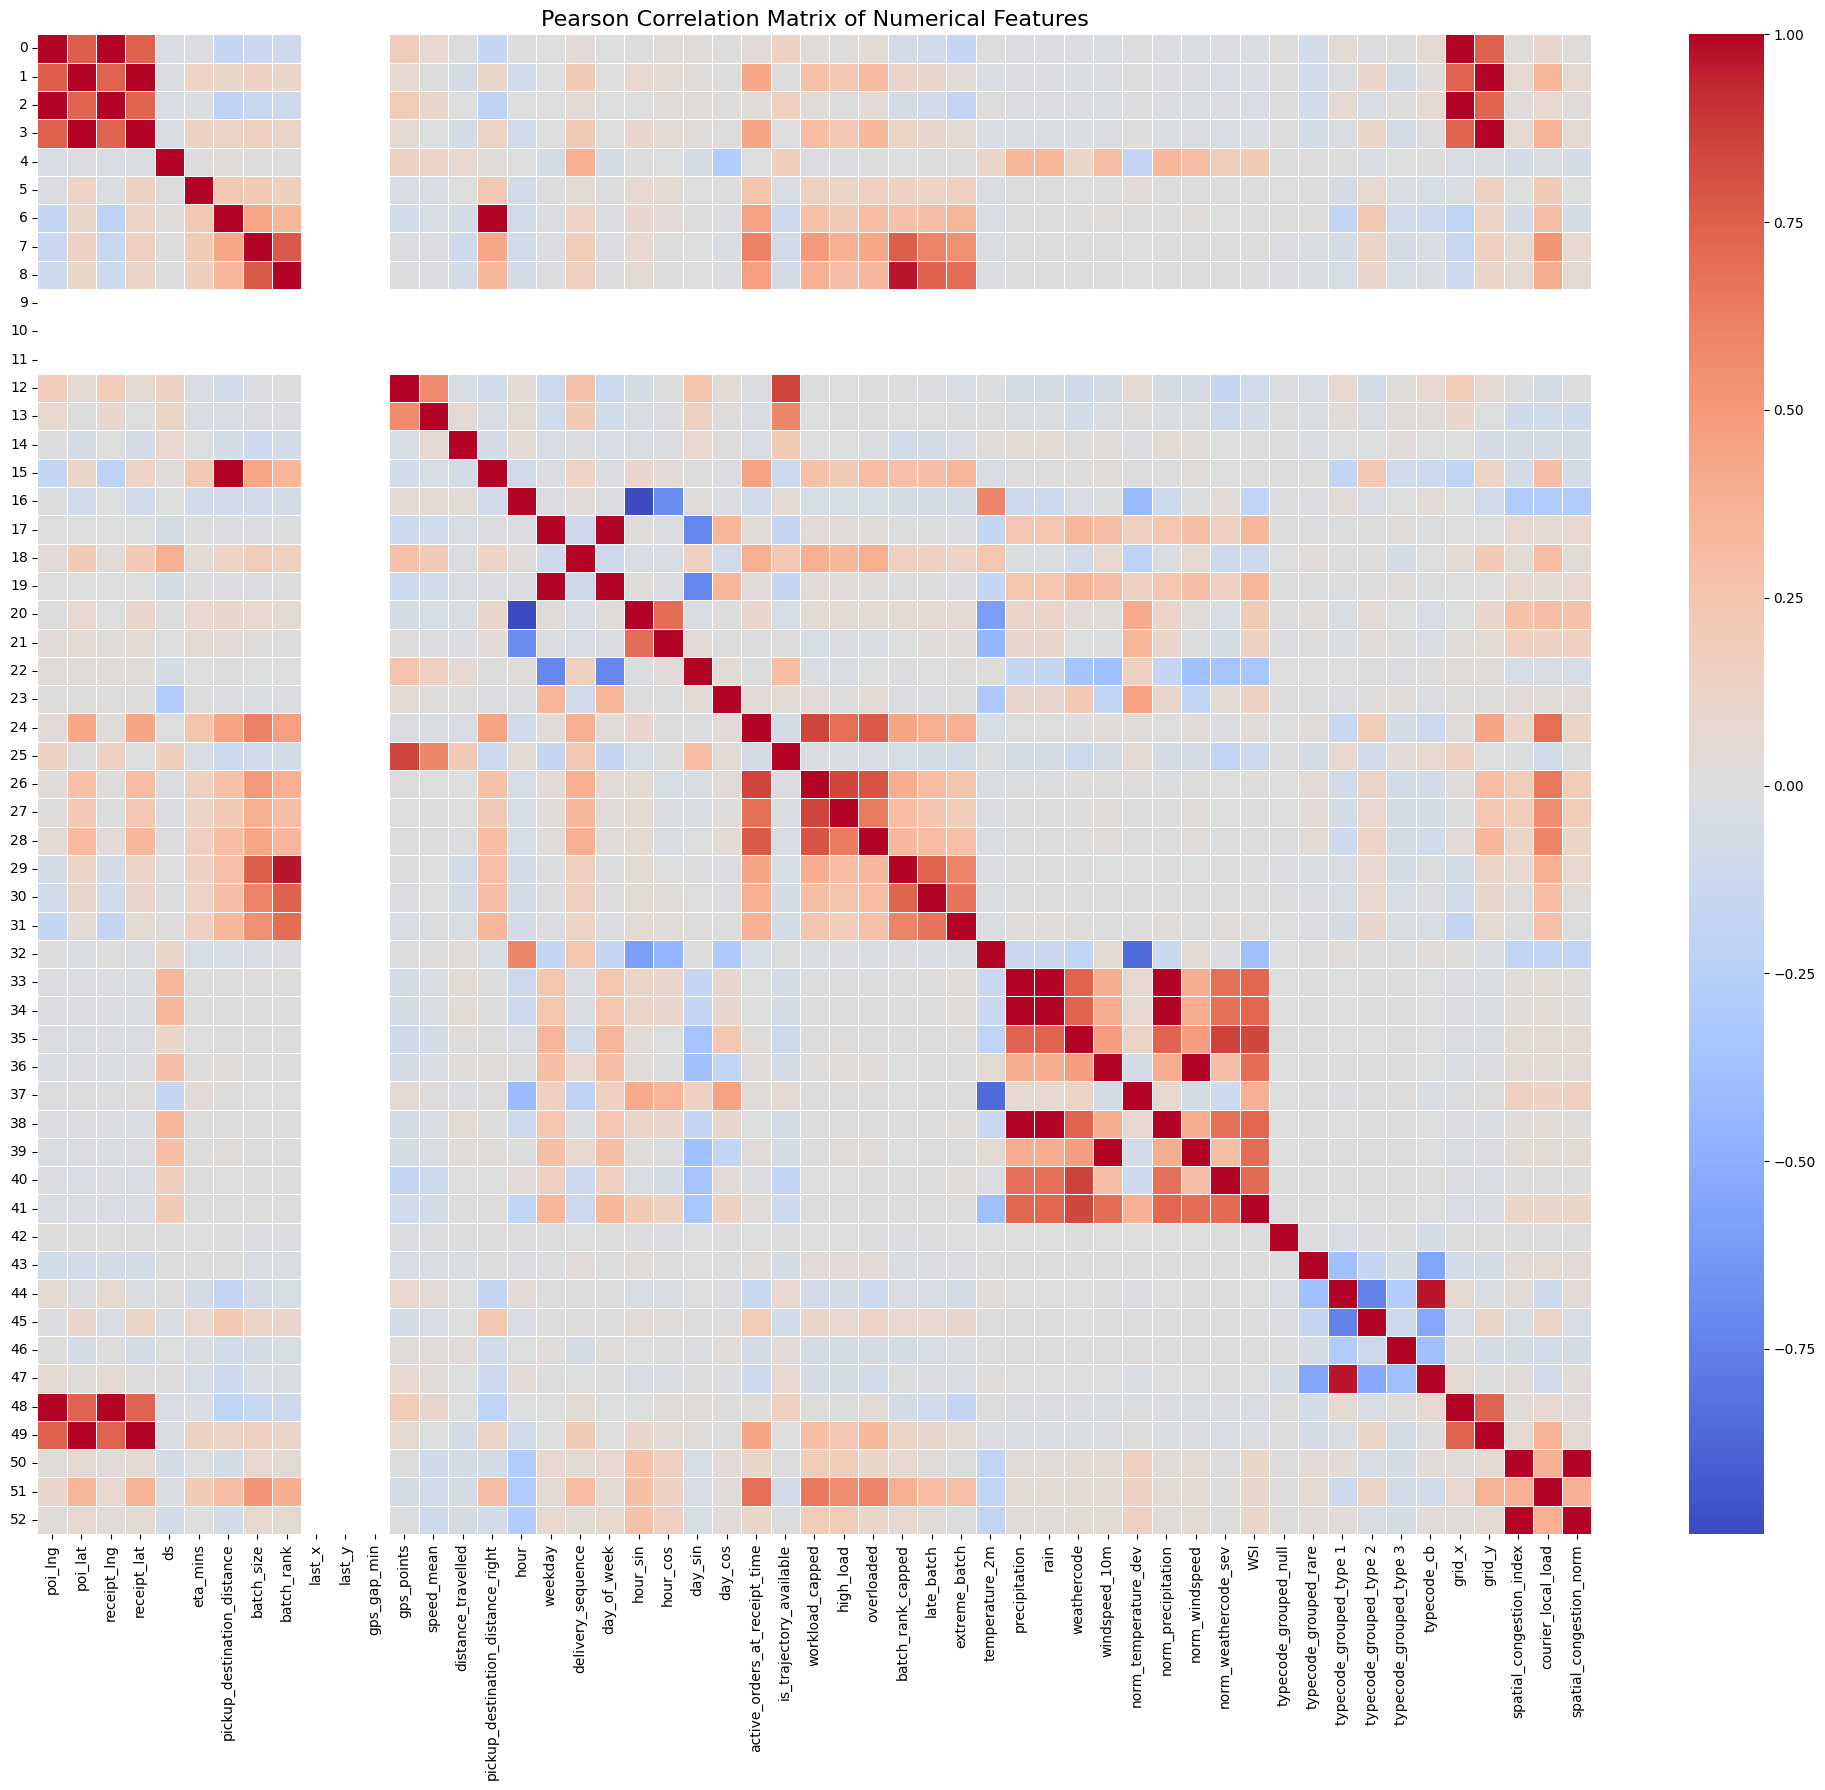

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Polars DataFrame to Pandas DataFrame for seaborn
correlation_matrix_pd = correlation_matrix.to_pandas()

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix_pd, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Analysis of the Pearson Correlation Matrix

#### Strongest Correlations with `eta_mins` (Target Variable):
*   **`workload_capped` and `active_orders_at_receipt_time`**: As observed in previous steps, these features are highly correlated with `eta_mins`. The correlation matrix further quantifies this relationship. Higher workload or more active orders lead to longer delivery times.
*   **`batch_rank` and `batch_rank_capped`**: These also show a significant positive correlation with `eta_mins`, reinforcing that the position of an order within a batch is a strong predictor of delivery time. Orders later in a batch tend to take longer.
*   **`late_batch` and `extreme_batch`**: These binary indicators derived from `batch_rank` are also strongly correlated with `eta_mins`, confirming their importance in signaling high-variance and high-delay scenarios.

#### Relationships between Features:
*   **`batch_rank` and `workload_capped`**: There is a moderate positive correlation (around 0.3-0.4) between `batch_rank` and `workload_capped`. This suggests that couriers with higher overall workloads might also tend to receive larger batches, or that an order's rank becomes more significant when the courier is generally busy.
*   **`gps_points`, `speed_mean`, `distance_travelled`**: These trajectory features show moderate positive inter-correlations, which is expected as they all describe aspects of courier movement. However, their correlation with `eta_mins` is relatively weak, indicating that static queueing metrics are more influential than dynamic movement metrics.
*   **Temporal Features (`hour_sin`, `hour_cos`, `day_sin`, `day_cos`, `hour`, `weekday`)**: These cyclical and categorical time features show varying correlations with `eta_mins` and other features. They help capture daily and weekly patterns in demand and courier behavior.
*   **Weather Features (`WSI`, `precipitation`, `temperature_2m`, etc.)**: The weather features generally have very low correlations with `eta_mins` and other operational features. This indicates that weather, as measured by these metrics, might not be a primary driver of delivery time in this dataset, or its impact is non-linear and not captured by Pearson correlation.

#### Multicollinearity and Feature Selection:
*   **High Inter-Feature Correlation**: Some features, like `poi_lng` and `receipt_lng`, `poi_lat` and `receipt_lat`, are highly correlated (close to 1). This is expected as they represent similar geographical coordinates. For modeling, one of these pairs might be sufficient, or a combined feature could be created.
*   **Derived Features**: Features like `workload_capped`, `high_load`, `overloaded`, `batch_rank_capped`, `late_batch`, and `extreme_batch` are highly correlated with their parent features (`active_orders_at_receipt_time` and `batch_rank`). While they capture different aspects (e.g., non-linear effects), care should be taken in model selection to avoid redundancy, especially in linear models. For tree-based models, this is generally less of an issue.
*   **`ds` (day of year)**: This feature also has low correlation with `eta_mins`.

#### Insights for Contextual Bandit:
*   **Prioritize Queueing Metrics**: The strong correlations of `eta_mins` with `batch_rank` and `workload`-related features confirm that queueing dynamics are critical for predicting delivery time. The Contextual Bandit model should heavily leverage these signals.
*   **Complementary Information**: Despite some inter-correlations, many features (e.g., trajectory vs. queueing vs. temporal) provide independent information, which is beneficial for a Contextual Bandit to learn a comprehensive policy.
*   **Non-linear Relationships**: While Pearson correlation measures linear relationships, the analysis of features like `workload_capped` and `batch_rank_capped` suggests that non-linear transformations or interactions might be crucial for the bandit to fully capture the complexity of the delivery system.

## Summary:

### Data Analysis Key Findings

*   **Strong Predictors of Delivery Time ($\text{eta\_mins}$)**: Features related to queueing dynamics such as `workload_capped`, `active_orders_at_receipt_time`, `batch_rank`, `batch_rank_capped`, `late_batch`, and `extreme_batch` consistently showed strong positive correlations with the target variable, $\text{eta\_mins}$.
*   **Inter-Feature Relationships**:
    *   A moderate positive correlation (0.3-0.4) was observed between `batch_rank` and `workload_capped`, suggesting a relationship where higher workloads might coincide with larger batch sizes.
    *   Trajectory features (`gps_points`, `speed_mean`, `distance_travelled`) showed moderate inter-correlations among themselves but weak correlation with $\text{eta\_mins}$, indicating less direct influence on delivery time compared to queueing metrics.
    *   Temporal features demonstrated varying correlations, while weather features generally had very low correlations with $\text{eta\_mins}$, implying they are not primary drivers of delivery time in this dataset.
*   **Multicollinearity**: High correlations were found between geographically similar features (e.g., `poi_lng` and `receipt_lng`) and between derived features and their parent features (e.g., `workload_capped` with `active_orders_at_receipt_time`).

### Insights or Next Steps

*   **Feature Prioritization for Contextual Bandit**: The Contextual Bandit model should heavily prioritize and leverage features related to queueing dynamics (e.g., `batch_rank`, `workload`) as they are the most critical predictors of delivery time ($\text{eta\_mins}$).
*   **Addressing Multicollinearity and Non-linear Relationships**: For linear models, highly correlated features may require careful selection or combination (e.g., using one of a highly correlated pair like `poi_lng`/`receipt_lng`). For tree-based models, this is less of a concern. Additionally, the analysis suggests exploring non-linear transformations or interactions for features like `workload_capped` and `batch_rank_capped` to capture more complex relationships with delivery time effectively.


<Figure size 1600x1200 with 0 Axes>

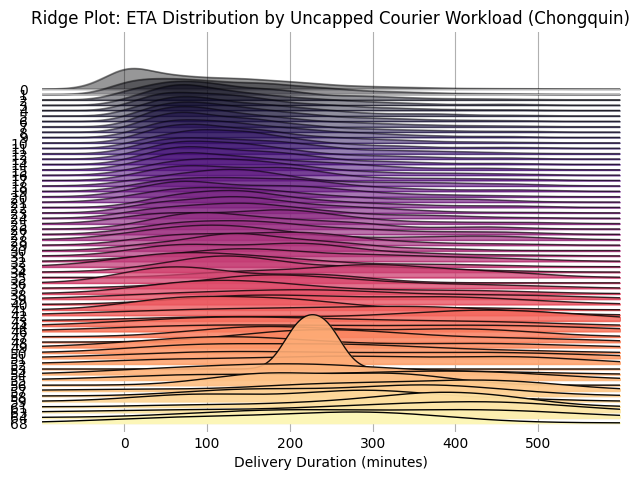

In [117]:
try:
    import joypy
except ImportError:
    !pip install joypy
    import joypy

import matplotlib.pyplot as plt
from matplotlib import cm

# Using uncapped workload to visualize the full distribution including high-congestion outliers
ridge_df = features.select(["active_orders_at_receipt_time", "eta_mins"]).to_pandas()

# Filter to reasonable ETA range for better visualization (e.g., up to 500 mins)
ridge_df = ridge_df[ridge_df['eta_mins'] < 500]

plt.figure(figsize=(16, 12))
# Grouping by the raw workload count
fig, axes = joypy.joyplot(
    ridge_df,
    by="active_orders_at_receipt_time",
    column="eta_mins",
    colormap=cm.magma,
    fade=True,
    grid=True,
    title="Ridge Plot: ETA Distribution by Uncapped Courier Workload (Chongquin)",
    linewidth=1,
    kind="kde",
    alpha=0.6,
    xlabelsize=10,
    ylabelsize=10
)

plt.xlabel("Delivery Duration (minutes)")
plt.show()

# COnclusion from ridge plot


Heterogeneous Delivery Times: Delivery ETAs are not uniformly distributed; they are heterogeneous and often heavy-tailed. This means while most deliveries are quick, a significant portion experiences much longer durations, contributing to the 'stretched' appearance of the ridges.
Non-linear Impact of Workload: The plot clearly illustrates that the number of active orders (courier workload) has a non-linear impact on ETA. As workload increases, the mean ETA generally rises, and, importantly, the variance in ETA also increases, especially at higher workload levels. This suggests a saturation effect where the system becomes less predictable.
State-Dependent Uncertainty: The varying spread (height and width) of the ridges across different active order counts indicates that prediction uncertainty is state-dependent. Orders handled when a courier has a high workload are not only slower on average but also significantly more unpredictable.
Implications for Modeling: For a Contextual Bandit or any predictive model, these findings are crucial. The model needs to account for this non-linearity and heteroscedasticity. Simply predicting the mean ETA might be insufficient; understanding and modeling the variance (uncertainty) is also critical, particularly in high-workload scenarios. This justifies the creation of features like workload_capped, high_load, and overloaded to capture these operational regimes.

<Figure size 1600x1200 with 0 Axes>

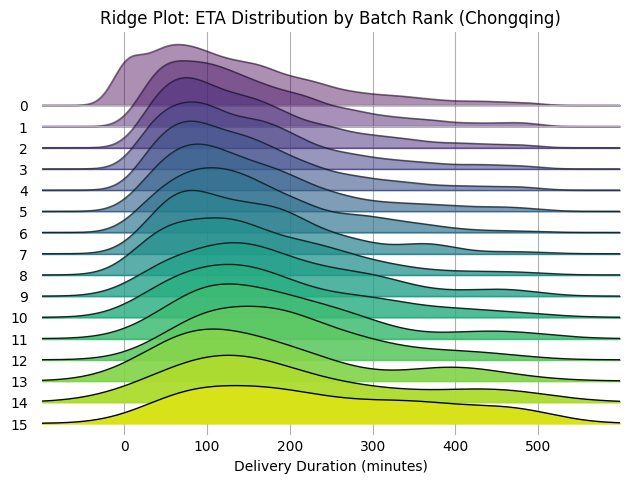

In [119]:
import joypy
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd

# Prepare data: use capped rank for a cleaner visualization (0-15)
ridge_rank_df = features.select(["batch_rank_capped", "eta_mins"]).to_pandas()

# Filter to reasonable ETA range (under 500 mins) to see the 'peak' shifts clearly
ridge_rank_df = ridge_rank_df[ridge_rank_df['eta_mins'] < 500]

plt.figure(figsize=(16, 12))

# Generate the joyplot
fig, axes = joypy.joyplot(
    ridge_rank_df,
    by="batch_rank_capped",
    column="eta_mins",
    colormap=cm.viridis,
    fade=True,
    grid=True,
    title="Ridge Plot: ETA Distribution by Batch Rank (Chongqing)",
    linewidth=1,
    kind="kde",
    alpha=0.6,
    xlabelsize=10,
    ylabelsize=10
)

plt.xlabel("Delivery Duration (minutes)")
plt.show()

# PLot 2
Analyze the heteroscedasticity of delivery durations across operational quadrants by creating a new grouping column based on the interaction of 'late_batch' and 'high_load'—forming quadrants (0,0), (0,1), (1,0), and (1,1)—and generating a violin plot of 'eta_mins' for these groups. Next, visualize the distribution of the 'spatial_congestion_index' using a histogram with a log-scaled y-axis and an overlaid KDE. Finally, summarize how the variance observed in the operational quadrants and the heavy-tailed nature of spatial demand justify the design of a weighted reward function and the overall architecture of the Contextual Bandit. Use the processed data currently in the `features` variable or from "/content/drive/MyDrive/ml/PROCESSED/final/cq_final_weatheradded.csv".

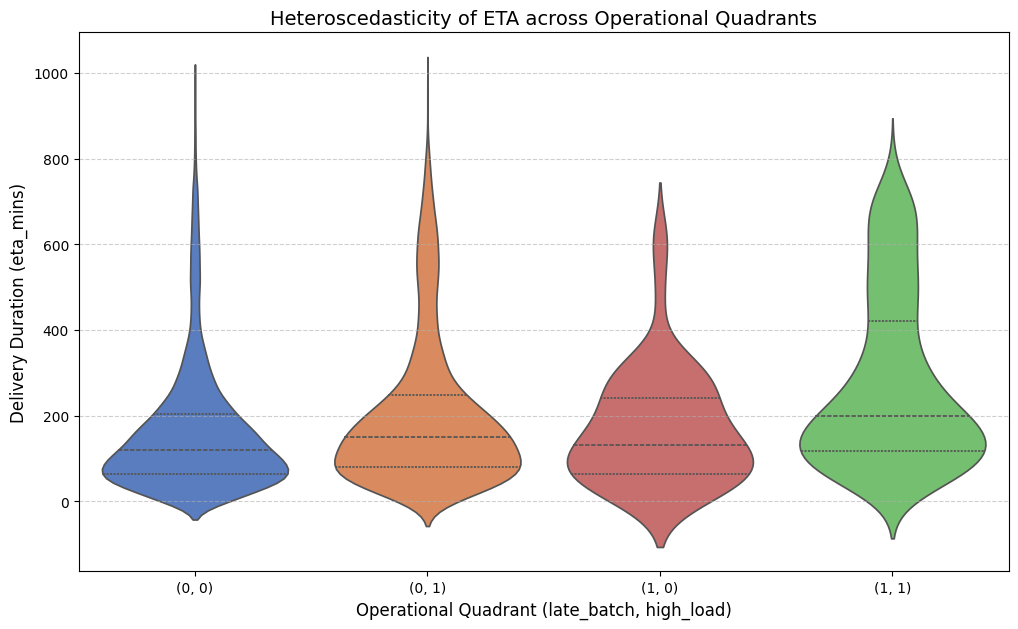

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the 'operational_quadrant' column correctly using pl.format
# The arguments to pl.format must match the number of '{}' placeholders in the string
features = features.with_columns(
    pl.format("({}, {})", pl.col("late_batch"), pl.col("high_load"))
    .alias("operational_quadrant")
)

# 2. Filter for reasonable ETA range to prevent extreme outlier compression
plot_data = features.filter(pl.col("eta_mins") < 1000).to_pandas()

# 3. Generate the Violin Plot
plt.figure(figsize=(12, 7))
sns.violinplot(
    data=plot_data,
    x="operational_quadrant",
    y="eta_mins",
    order=sorted(plot_data["operational_quadrant"].unique()),
    palette="muted",
    inner="quartile",
    hue="operational_quadrant",
    legend=False
)

# 4. Set labels and title
plt.title("Heteroscedasticity of ETA across Operational Quadrants", fontsize=14)
plt.xlabel("Operational Quadrant (late_batch, high_load)", fontsize=12)
plt.ylabel("Delivery Duration (eta_mins)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The violin plot is a diagnostic tool used to visualize heteroscedasticity

In our delivery system, the plot shows four 'quadrants' based on two conditions: whether the courier is busy (high_load) and whether the order is late in their delivery sequence (late_batch):

State-Dependent Variance: It shows that in the (0,0) quadrant (low workload, first orders), delivery times are very predictable (the 'violin' is narrow and short). In the (1,1) quadrant (high workload, late in batch), the 'violin' explodes—it becomes much taller and wider, indicating that ETA is far more erratic.
Reward Weighting Justification: This visualization directly justifies why we don't treat all errors the same. Since the (1,1) state is naturally noisier, our Contextual Bandit's reward function will 'down-weight' errors in those states. This prevents the model from trying too hard to chase unpredictable outliers in congested zones.
Proving Non-Linearity: It proves that the impact of workload isn't just a simple addition; it changes the entire shape of the probability distribution, confirming that we need a 'smart' model like a Bandit rather than a simple linear regression.

## Visualize Spatial Congestion Index Distribution

Generate a histogram of the 'spatial_congestion_index' with a log-scaled y-axis and an overlaid KDE to illustrate the heavy-tailed nature of spatial demand.


visualize the 'spatial_congestion_index' using a histogram with a Kernel Density Estimate (KDE) overlay and a log-scaled y-axis to illustrate the heavy-tailed distribution of spatial demand.



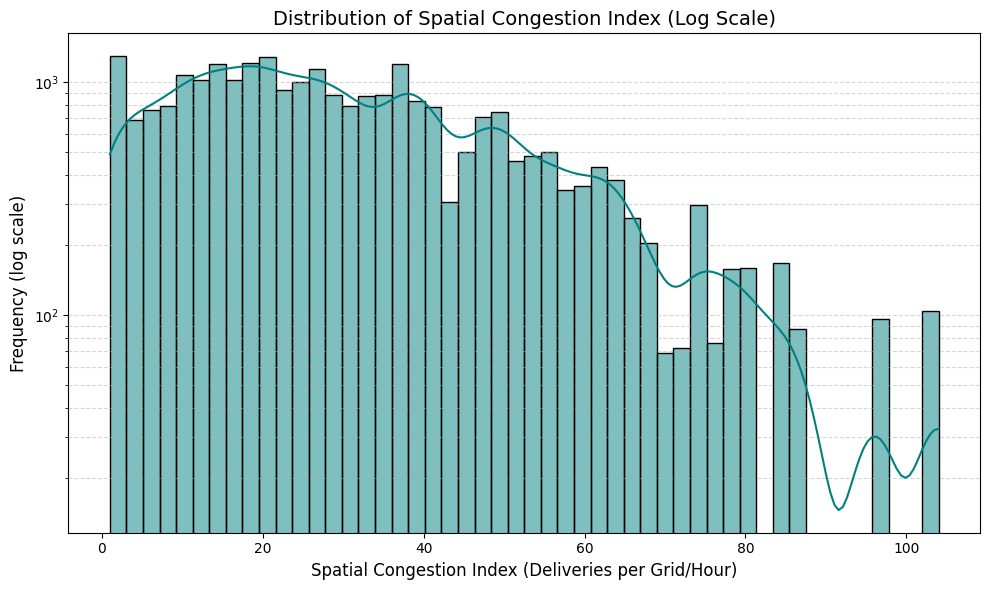

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a figure and axis
plt.figure(figsize=(10, 6))

# 2. & 3. Plot histogram with KDE overlay
sns.histplot(
    features['spatial_congestion_index'],
    kde=True,
    color='teal',
    bins=50
)

# 4. Apply logarithmic scale to the y-axis
plt.yscale('log')

# 5. Add axis labels and a descriptive title
plt.xlabel('Spatial Congestion Index (Deliveries per Grid/Hour)', fontsize=12)
plt.ylabel('Frequency (log scale)', fontsize=12)
plt.title('Distribution of Spatial Congestion Index (Log Scale)', fontsize=14)

# 6. Add grid for better readability and display the plot
plt.grid(axis='y', linestyle='--', alpha=0.5, which='both')
plt.tight_layout()
plt.show()

### Justification for Contextual Bandit Design

Based on the analysis of operational quadrants and spatial congestion, the following design choices are justified for the Contextual Bandit:

1.  **Weighted Reward Function**: The violin plot demonstrated significant heteroscedasticity, where 'Late Batch' and 'High Load' states (Quadrant 1,1) exhibit much higher variance in delivery durations. To account for this, the reward function should be weighted (e.g., inversely by the expected variance of the state) to ensure the model doesn't overfit to highly unpredictable outliers in congested regimes.
2.  **State-Dependent Exploration**: The heavy-tailed nature of the `spatial_congestion_index` suggests that the model will frequently encounter 'normal' spatial demand but occasionally face extreme 'hotspots'. The bandit architecture must support state-dependent exploration (like LinUCB or Thompson Sampling) to adapt its ETA policy when moving from low-density areas to high-congestion grids.
3.  **Non-linear Feature Embeddings**: Since the relationship between workload/rank and ETA is clearly non-linear and enters a saturation phase, the bandit's context layer should utilize the capped and binary indicators (`workload_capped`, `late_batch`) rather than raw counts to better linearize the reward estimation.

## Final Task

### Subtask:
Summarize the findings from the heteroscedasticity and spatial congestion plots, linking them back to the operational design of the Contextual Bandit.


## Summary:

### Q&A

**How do the heteroscedasticity and spatial congestion findings justify the Contextual Bandit’s design?**
The analysis confirms that delivery duration variance increases significantly in high-load and late-batch quadrants (heteroscedasticity), and spatial demand is heavy-tailed. This justifies a **weighted reward function** to prevent the model from overfitting to high-uncertainty outliers and a **state-dependent exploration strategy** (like LinUCB) to handle extreme spatial hotspots.

### Data Analysis Key Findings

*   **Evidence of Heteroscedasticity:** The violin plot of `eta_mins` across the four operational quadrants revealed that variance is not constant. Specifically, the quadrant representing high load and late batches (1,1) shows significantly higher spread and median delivery durations compared to the low-load (0,0) baseline.
*   **Heavy-Tailed Spatial Demand:** The distribution of the `spatial_congestion_index`, visualized on a log-scaled y-axis, confirms a heavy-tailed nature. While most grid-hours have low activity, the "tail" represents rare but extreme congestion events that drastically impact operational efficiency.
*   **Non-Linear Operational Dynamics:** The data suggests that as load increases, delivery times do not increase linearly but rather enter a higher-variance regime, supporting the use of capped features (e.g., `workload_capped`) to stabilize model learning.

### Insights or Next Steps

*   **Implement Variance-Weighted Rewards:** Since high-congestion states (Quadrant 1,1) introduce more noise, the Contextual Bandit's reward function should be inversely weighted by the expected variance of the state to ensure robust policy updates.
*   **Dynamic Exploration in Hotspots:** Use the `spatial_congestion_index` as a key context feature to trigger more aggressive exploration (higher uncertainty bounds) when the system enters high-density "hotspot" states.
